[[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]]
[[13.121977564163586, 200], [1.1885063357683883, 27], [47.5172386318743, 174], [0.4623857587430634, 49], [16.820156247927727, 142], [36.22046685082749, 145], [17.093127157843828, 73], [0, 35], [0, 7], [6.1317068618128205, 53], [4.963759502206428, 38], [1.6205495309800182, 137], [2.388998487045119, 119], [39.21825591917224, 157], [20.978815417476675, 97], [1.802612408452346, 118], [1.6401303538634124, 94]]
[0.06560988782081793, 0.04401875317660697, 0.2730875783441052, 0.009436444055980887, 0.11845180456287131, 0.24979632310915512, 0.23415242681977846, 0.0, 0.0, 0.1156925822983551, 0.13062525005806389, 0.011828828693284804, 0.020075617538194278, 0.24979780840237098, 0.2162764476028523, 0.015276376342816492, 0.01744819525386609]


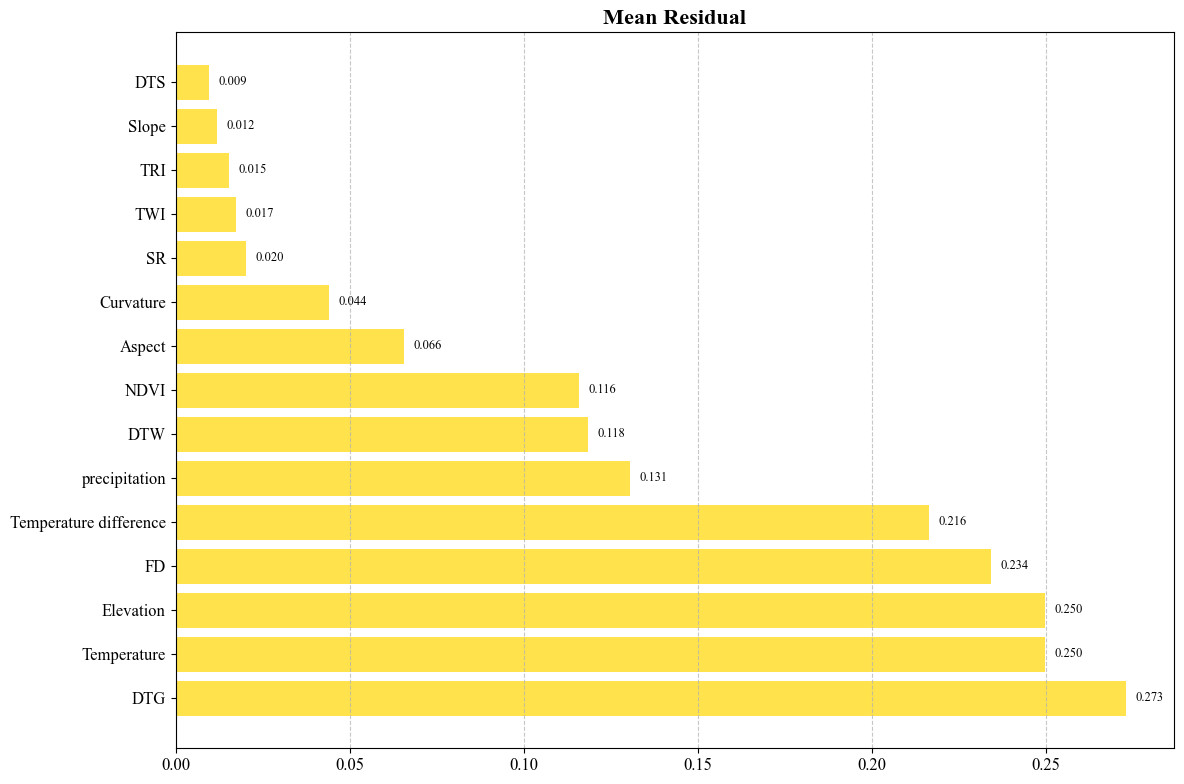

因子值从小到大排序 (已过滤值为0的因子):
索引	英文名			中文名		值
3	DTS                 	distance to stream	0.009436
11	Slope               	坡度        	0.011829
15	TRI                 	topographic roughness index	0.015276
16	TWI                 	topographic wetness index	0.017448
12	SR                  	solar radiation	0.020076
1	Curvature           	曲率        	0.044019
0	Aspect              	坡向        	0.065610
9	NDVI                	归一化植被指数   	0.115693
4	DTW                 	distance to water bodies	0.118452
10	precipitation       	precipitation 降水	0.130625
14	Temperature difference	年温度差异     	0.216276
6	FD                  	fault density	0.234152
5	Elevation           	高程        	0.249796
13	Temperature         	1-6月平均温度  	0.249798
2	DTG                 	distance to glacier	0.273088

被过滤掉的因子 (值为0):
7	Geology             	地质        
8	LULC                	land use & land cover
[[0.4491952772071599, 0.396], [0.0132653424640963, 0.145], [-0.279820212, -0.359], [-0.751695016, -0.795], [-0.82261011, -0.82], [-0.89

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取csv1和csv2
csv1 = pd.read_csv('lowess_cf_distribution/quan_factors_cf.csv').values
csv2 = pd.read_csv('lowess_cf_distribution/plot_sts.csv').values
# factor_index	boundary	num	CF	left	right
# idx	lowess_y	x	num
sts=[[0,0] for i in range(17)]
print(sts)
test=[]
for a in csv2:
    idx=int(a[0])
    x=a[2]
    # if idx ==3 or idx==6:
    #     x/=1e5
    lowess_y=a[1]
    sts[idx][1]+=1
    for b in csv1:
        CF,left,right=b[3],b[4],b[5]
        if idx == b[0] and x<=right and x>left:
            sts[idx][0]+=abs(lowess_y-CF)
            if idx==3:
                test.append([lowess_y,CF])

# sts=np.array(sts)
# print(sts)
#
# res=sts[:0]/sts[:1]
print(sts)
result = [item[0]/item[1] for item in sts]
print(result)
factor_map = {
    0:  ("Aspect", "坡向"),
    1:  ("Curvature", "曲率"),
    2:  ("DTG", "distance to glacier"),
    3:  ("DTS", "distance to stream"),
    4:  ("DTW", "distance to water bodies") ,
    5:  ("Elevation", "高程"),
    6:  ("FD", "fault density"),
    7:  ("Geology", "地质"),
    8:  ("LULC", "land use & land cover"),
    9:  ("NDVI", "归一化植被指数"),
    10: ("precipitation", "precipitation 降水"),
    11: ("Slope", "坡度"),
    12: ("SR", "solar radiation"),
    13: ("Temperature", "1-6月平均温度"),
    14: ("Temperature difference", "年温度差异"),
    15: ("TRI", "topographic roughness index"),
    16: ("TWI", "topographic wetness index")
}
plt.rcParams.update({
    'font.family': 'serif',  # 使用衬线字体
    'font.serif': ['Times New Roman'],  # 指定Times New Roman
    'font.size': 12,  # 基础字体大小
    'axes.labelsize': 14,  # 坐标轴标签字体大小
    'axes.titlesize': 16,  # 标题字体大小
    'xtick.labelsize': 12,  # x轴刻度标签字体大小
    'ytick.labelsize': 12,  # y轴刻度标签字体大小
    'legend.fontsize': 12,  # 图例字体大小
    'figure.titlesize': 18,  # 图形总标题字体大小
})
# 创建数据对列表，包含索引、值和因子名称，并过滤掉值为0的因子
data_pairs = []
for i, value in enumerate(result):
    if i not in[7,8]:  # 只保留值不为0的因子
        eng_name, chi_name = factor_map[i]
        data_pairs.append((i, value, eng_name))

# 按值从小到大排序
data_pairs.sort(key=lambda x: x[1])

# 提取排序后的数据
sorted_indices = [pair[0] for pair in data_pairs]
sorted_values = [pair[1] for pair in data_pairs]
sorted_labels = [pair[2] for pair in data_pairs]

# 创建图表 - 关键修改：反转y轴，使最小值在最上面
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(sorted_values)), sorted_values, color='gold', alpha=0.7)
plt.yticks(range(len(sorted_labels)), sorted_labels)
plt.title('Mean Residual',fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 反转y轴，使最小值在最上面
plt.gca().invert_yaxis()

# 在条形上添加数值标签
for i, (bar, value) in enumerate(zip(bars, sorted_values)):
    plt.text(bar.get_width() + max(sorted_values)*0.01, bar.get_y() + bar.get_height()/2,
             f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('lowess_cf_distribution/Mean Residual.png',dpi=600)
plt.show()

# 打印排序后的表格
print("因子值从小到大排序 (已过滤值为0的因子):")
print("索引\t英文名\t\t\t中文名\t\t值")
for i, (idx, value, label) in enumerate(data_pairs):
    eng_name, chi_name = factor_map[idx]
    print(f"{idx}\t{eng_name:20}\t{chi_name:10}\t{value:.6f}")

# 打印被过滤掉的因子
zero_factors = []
for i, value in enumerate(result):
    if value == 0:
        eng_name, chi_name = factor_map[i]
        zero_factors.append((i, eng_name, chi_name))

if zero_factors:
    print("\n被过滤掉的因子 (值为0):")
    for idx, eng_name, chi_name in zero_factors:
        print(f"{idx}\t{eng_name:20}\t{chi_name:10}")
print(test)

In [3]:
import mpmath
import numpy as np
from shapely.lib import distance
from tensorflow.python.layers.core import dropout

# 假设原始数组形状为 (4909, 8050, 1)
original_array = np.random.rand(3, 3, 1)  # 示例数组

# 转换为 (1, 1, 4909, 8050)
transformed_array = original_array.reshape(1, 1, 3, 3)

print("原始形状:", original_array)
print("转换后形状:", transformed_array)

原始形状: [[[0.24712223]
  [0.10626145]
  [0.0825546 ]]

 [[0.92278263]
  [0.75368173]
  [0.08720389]]

 [[0.17400234]
  [0.86057343]
  [0.5658929 ]]]
转换后形状: [[[[0.24712223 0.10626145 0.0825546 ]
   [0.92278263 0.75368173 0.08720389]
   [0.17400234 0.86057343 0.5658929 ]]]]


In [4]:
import numpy as np
from sklearn.ensemble import IsolationForest

# 创建示例数据
X = np.array([[1], [2], [3], [10], [100]])  # 最后两个可能是异常值

# 训练模型
iso_forest = IsolationForest(random_state=42, contamination=0.1)
iso_forest.fit(X)

# 获取分数和预测
scores = iso_forest.decision_function(X)
predictions = iso_forest.predict(X)

print("样本数据:", X.flatten())
print("异常分数:", scores.round(3))
print("预测结果:", predictions)
print("模型阈值 (offset_):", iso_forest.offset_.round(3))

# 手动验证预测逻辑
manual_predictions = np.where(scores < iso_forest.offset_, 1, -1)
print("手动预测:", manual_predictions)
print("预测是否一致:", np.array_equal(predictions, manual_predictions))

样本数据: [  1   2   3  10 100]
异常分数: [ 0.245  0.316  0.283  0.118 -0.079]
预测结果: [ 1  1  1  1 -1]
模型阈值 (offset_): -0.638
手动预测: [-1 -1 -1 -1 -1]
预测是否一致: False


In [ ]:
from osgeo import gdal, ogr

# 方法1: 使用GDAL打开OSGB文件
def open_osgb_with_gdal(file_path):
    """使用GDAL打开OSGB文件"""
    try:
        dataset = gdal.Open(file_path)
        if dataset is None:
            print("无法打开文件")
            return None

        print(f"文件打开成功")
        print(f"波段数: {dataset.RasterCount}")
        print(f"图像大小: {dataset.RasterXSize} x {dataset.RasterYSize}")

        return dataset
    except Exception as e:
        print(f"打开文件时出错: {e}")
        return None

# 使用示例
dataset = open_osgb_with_gdal("")

In [3]:
import numpy as np
mn,mx=-1,1
steps = np.round(np.linspace(mn, mx, 2),4)
print(steps)

[-1.  1.]


In [23]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
def plot_examples(colormaps):
    np.random.seed(19680801)
    data = np.random.rand(4, 50)
    n = 1
    fig, axs = plt.subplots(1, n, figsize=(n * 2 + 2, 3),
                            constrained_layout=True, squeeze=False)
    for [ax, cmap] in zip(axs.flat, colormaps):
        psm = ax.pcolormesh(data, cmap=cmap, rasterized=True, vmin=0, vmax=1)
        fig.colorbar(psm, ax=ax)
    plt.show()
color_map = {
    "nodata":(1,1,1),                       #空白
    "Low": (81/255, 137/255, 61/255),       # 51893D
    "Moderate": (186/255, 191/255, 44/255), # BABF2C
    "High": (242/255, 191/255, 39/255),     # F2BF27
    "Very High": (242/255, 65/255, 65/255)  # F24141
}
print(color_map.values())
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', list(color_map.values()), N=320)
# cmap = mcolors.LinearSegmentedColormap(name='1',segmentdata=color_map,N=360)
print(cmap)
# plot_examples(cmap)

dict_values([(1, 1, 1), (0.3176470588235294, 0.5372549019607843, 0.23921568627450981), (0.7294117647058823, 0.7490196078431373, 0.17254901960784313), (0.9490196078431372, 0.7490196078431373, 0.15294117647058825), (0.9490196078431372, 0.2549019607843137, 0.2549019607843137)])


In [ ]:
from sklearn.ensemble import IsolationForest
# print(help(IsolationForest.decision_function))


Accuracy: 0.7000
Precision: 0.8000
Recall: 0.6667
F1-Score: 0.7273
AUC: 0.9167

Confusion Matrix:
[[3 1]
 [2 4]]


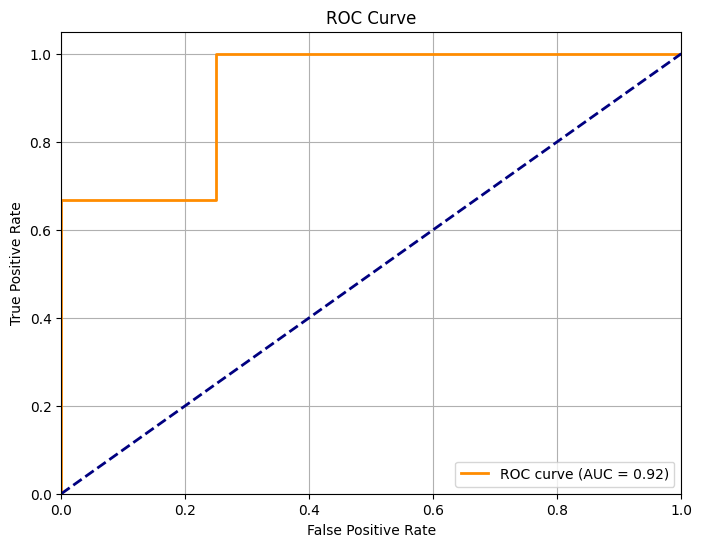


多分类示例:
Accuracy: 0.7778
Precision: 0.7778
Recall: 0.7778
F1-Score: 0.7778

Confusion Matrix:
[[3 0 0]
 [0 2 1]
 [0 1 2]]


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

def calculate_classification_metrics(y_true, y_pred, y_score=None, average='binary'):
    """
    计算分类任务的各项指标

    参数:
    y_true -- 真实标签
    y_pred -- 预测标签
    y_score -- 预测概率得分（用于ROC和AUC计算）
    average -- 多分类时的平均方法 ('binary', 'micro', 'macro', 'weighted')

    返回:
    包含各项指标的字典
    """
    metrics = {}

    # 基础指标
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average=average)
    metrics['recall'] = recall_score(y_true, y_pred, average=average)
    metrics['f1'] = f1_score(y_true, y_pred, average=average)

    # 计算混淆矩阵
    metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred)

    # 如果提供了预测概率，计算ROC和AUC
    if y_score is not None:
        if average == 'binary' or len(np.unique(y_true)) == 2:
            fpr, tpr, _ = roc_curve(y_true, y_score)
            metrics['roc_curve'] = (fpr, tpr)
            metrics['auc'] = auc(fpr, tpr)
        else:
            # 多分类ROC曲线处理（需要更复杂的处理）
            pass

    return metrics

def plot_roc_curve(fpr, tpr, auc_score, title='ROC Curve'):
    """
    绘制ROC曲线

    参数:
    fpr -- 假正率
    tpr -- 真正率
    auc_score -- AUC值
    title -- 图表标题
    """
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def print_classification_report(metrics, target_names=None):
    """
    打印分类报告

    参数:
    metrics -- 包含指标的字典
    target_names -- 类别名称
    """
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")

    if 'auc' in metrics:
        print(f"AUC: {metrics['auc']:.4f}")

    print("\nConfusion Matrix:")
    print(metrics['confusion_matrix'])

# 使用示例
if __name__ == "__main__":
    # 示例数据（二分类）
    y_true = np.array([0, 1, 0, 1, 1, 0, 0, 1, 1, 1])
    y_pred = np.array([0, 1, 0, 0, 1, 0, 1, 1, 1, 0])
    y_score = np.array([0.1, 0.9, 0.2, 0.4, 0.8, 0.3, 0.6, 0.85, 0.95, 0.45])

    # 计算指标
    metrics = calculate_classification_metrics(y_true, y_pred, y_score)

    # 打印报告
    print_classification_report(metrics)

    # 绘制ROC曲线（如果可用）
    if 'roc_curve' in metrics:
        fpr, tpr = metrics['roc_curve']
        plot_roc_curve(fpr, tpr, metrics['auc'])

    # 多分类示例
    print("\n多分类示例:")
    y_true_multi = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2])
    y_pred_multi = np.array([0, 1, 1, 0, 2, 2, 0, 1, 2])

    metrics_multi = calculate_classification_metrics(
        y_true_multi, y_pred_multi, average='macro'
    )
    print_classification_report(metrics_multi)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


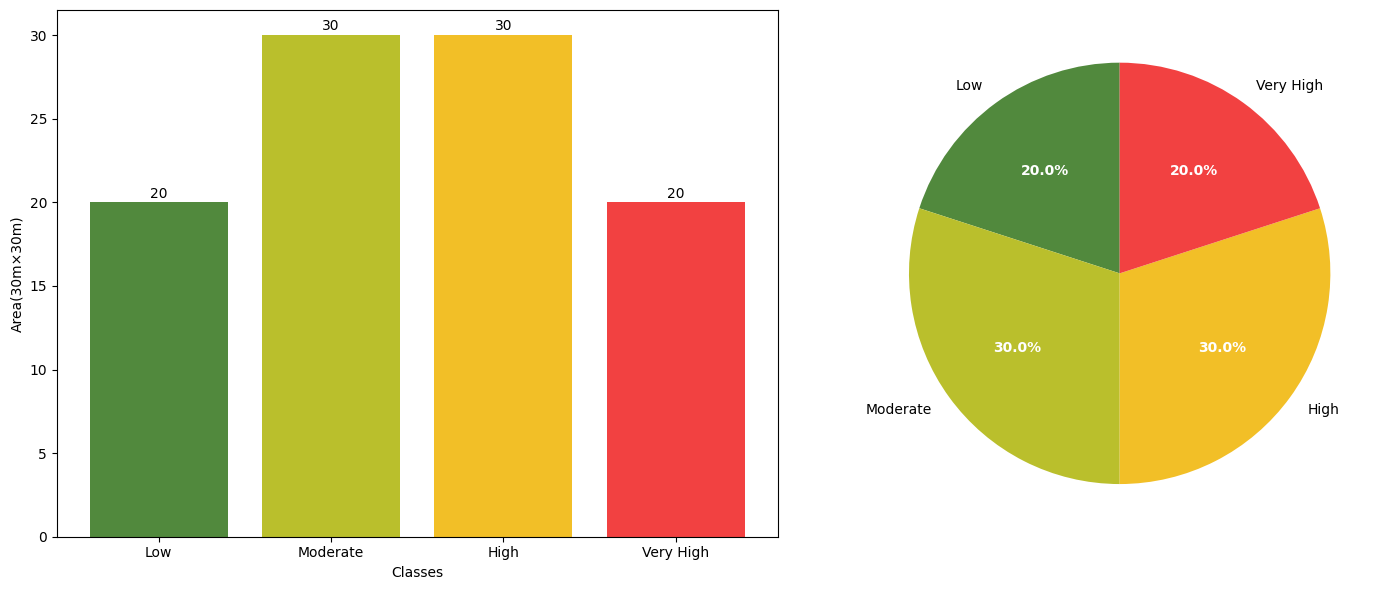

分类阈值: [ 0.  19.8 49.5 79.2 99. ]
各类别像素数量: [20 30 30 20]
各类别百分比: [20. 30. 30. 20.]


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def res_sts(map_arr: np.array, rate: np.array,model:str):
    '''
    map_arr: 去除nodata的map.flatten
    rate: 分成几类，每类的值的比例，如分为class0的值的范围为：(min,min+rate[0]*(max-min))
           例如：[0, 0.333, 0.666, 1]
    出统计图
    '''
    min_val = np.min(map_arr)
    max_val = np.max(map_arr)
    thresholds = min_val + rate * (max_val - min_val)
    classified = np.digitize(map_arr, thresholds[:-1])
    class_counts = np.bincount(classified, minlength=len(rate))
    percentages = class_counts / len(map_arr) * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    colors = {
          "Low": (81/255, 137/255, 61/255),       # 51893D
          "Moderate": (186/255, 191/255, 44/255), # BABF2C
          "High": (242/255, 191/255, 39/255),     # F2BF27
          "Very High": (242/255, 65/255, 65/255)  # F24141
    }
    classes = list(colors.keys())
    colors=list(colors.values())


    bars = ax1.bar(classes, class_counts[1:], color=colors)
    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Area(30m×30m)')
    for bar, count in zip(bars, class_counts[1:]):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{count:,}', ha='center', va='bottom')

    # 绘制饼图
    wedges, texts, autotexts = ax2.pie(percentages[1:], labels=classes, autopct='%1.1f%%',
                                       colors=colors, startangle=90)
    # 美化饼图文本
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    # 添加图例，显示各类别的数值范围
    # legend_labels = []
    # for i in range(len(rate)-1):
    #     lower = thresholds[i]
    #     upper = thresholds[i+1]
    #     legend_labels.append(f'{classes[i]}: [{lower:.2f}, {upper:.2f})')
    #
    # # fig.legend(legend_labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0))
    # fig.legend(wedges, labels=legend_labels, loc='lower center', bbox_to_anchor=(0.5, 1))


    # 调整布局
    plt.tight_layout()
    # plt.title()
    # plt.subplots_adjust(bottom=0.2)

    # 显示图表
    plt.show()

    # 返回分类结果和统计信息
    return {
        'thresholds': thresholds,
        'class_counts': class_counts[1:],
        'percentages': percentages[1:]
    }

# 示例使用
if __name__ == "__main__":
    # 生成示例数据
    np.random.seed(42)
    data=np.arange(100)
    print(data)

    # 定义分类比例
    rate = np.array([0, 0.2, 0.5, 0.8, 1.0])

    # 调用函数
    result = res_sts(data, rate,'test')

    # 打印统计结果
    print("分类阈值:", result['thresholds'])
    print("各类别像素数量:", result['class_counts'])
    print("各类别百分比:", result['percentages'])

In [22]:
map_arr = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2])
max_val = np.max(map_arr)

NameError: name 'dtype' is not defined

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('data.dat', delimiter='\s+')  # 以空格分隔
data = df.to_numpy()
data=np.arange(100)
print(data.shape)
mx,mn=np.max(data),np.min(data)
data=255*(data-mn)/(mx-mn)
print(data)
np.savetxt('data_new.dat', data,
           delimiter=',',   # 分隔符，可以是空格、逗号等
           fmt='%.6f',     # 格式字符串，控制精度
           comments='# ')   # 注释行的前缀

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
(100,)
[  0.           2.57575758   5.15151515   7.72727273  10.3030303
  12.87878788  15.45454545  18.03030303  20.60606061  23.18181818
  25.75757576  28.33333333  30.90909091  33.48484848  36.06060606
  38.63636364  41.21212121  43.78787879  46.36363636  48.93939394
  51.51515152  54.09090909  56.66666667  59.24242424  61.81818182
  64.39393939  66.96969697  69.54545455  72.12121212  74.6969697
  77.27272727  79.84848485  82.42424242  85.          87.57575758
  90.15151515  92.72727273  95.3030303   97.87878788 100.45454545
 103.03030303 105.60606061 108.18181818 110.75757576 113.33333333
 115.90909091 118.48484848 121.06060606 123.63636364 126.21212121
 128.78787879 131.36363636 13

混淆矩阵:
[[ 27   3]
 [  6 294]]

分类报告:
              precision    recall  f1-score   support

        -1.0       0.82      0.90      0.86        30
         1.0       0.99      0.98      0.98       300

    accuracy                           0.97       330
   macro avg       0.90      0.94      0.92       330
weighted avg       0.97      0.97      0.97       330



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41664\1442062727.py:71: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41664\1442062727.py:71: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41664\1442062727.py:71: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41664\1442062727.py:71: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41664\1442062727.py:71: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_41664\1442062727.py:71: UserWarning: Glyph 24

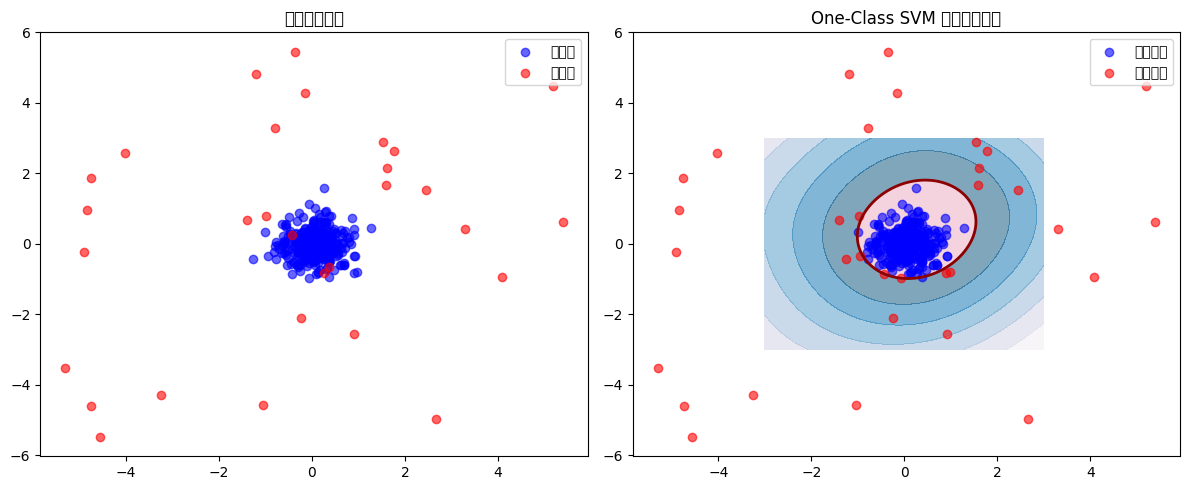


前10个样本的异常分数:
[ 0.73758265  0.82632991  0.62523757  0.81996988 -0.06341983  0.56134582
  0.65943607  0.80189989  0.58967482  0.62805783]

新样本检测结果:
样本 1: [0 0] -> 正常 (分数: 0.7584)
样本 2: [2 2] -> 异常 (分数: -3.4053)
样本 3: [-2 -2] -> 异常 (分数: -4.6224)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 设置随机种子以确保结果可重现
np.random.seed(42)

# 1. 生成示例数据
# 生成正常数据（内点）
n_normal = 300
normal_data, _ = make_blobs(n_samples=n_normal, centers=1, cluster_std=0.3, center_box=(0, 0))

# 生成异常数据（外点）
n_outliers = 30
outlier_data = np.random.uniform(low=-4, high=4, size=(n_outliers, 2))

# 合并数据
X = np.vstack([normal_data, outlier_data])
y = np.hstack([np.ones(n_normal), -1 * np.ones(n_outliers)])

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 训练One-Class SVM模型
# nu：异常值比例的上界和支持向量比例的下界
oc_svm = svm.OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
oc_svm.fit(X_scaled)

# 3. 预测
y_pred = oc_svm.predict(X_scaled)

# 4. 评估模型性能
print("混淆矩阵:")
print(confusion_matrix(y, y_pred))
print("\n分类报告:")
print(classification_report(y, y_pred))

# 5. 可视化结果
plt.figure(figsize=(12, 5))

# 绘制原始数据分布
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], c='blue', label='正常点', alpha=0.6)
plt.scatter(X_scaled[y == -1, 0], X_scaled[y == -1, 1], c='red', label='异常点', alpha=0.6)
plt.title('原始数据分布')
plt.legend()

# 绘制决策边界
plt.subplot(1, 2, 2)
# 创建网格以绘制决策边界
xx, yy = np.meshgrid(np.linspace(-3, 3, 500), np.linspace(-3, 3, 500))
Z = oc_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界和填充区域
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu, alpha=0.5)
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')
plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='palevioletred', alpha=0.3)

# 绘制数据点
plt.scatter(X_scaled[y_pred == 1, 0], X_scaled[y_pred == 1, 1], c='blue', label='预测正常', alpha=0.6)
plt.scatter(X_scaled[y_pred == -1, 0], X_scaled[y_pred == -1, 1], c='red', label='预测异常', alpha=0.6)

plt.title('One-Class SVM 异常检测结果')
plt.legend()

plt.tight_layout()
plt.show()

# 6. 获取异常分数（决策函数值）
decision_scores = oc_svm.decision_function(X_scaled)
print("\n前10个样本的异常分数:")
print(decision_scores[:10])
# 分数越低表示越可能是异常

# 7. 在实际应用中的使用示例
def detect_anomalies(new_data, model, scaler, threshold=None):
    """
    使用训练好的One-Class SVM检测新数据中的异常

    参数:
    new_data: 新数据点
    model: 训练好的One-Class SVM模型
    scaler: 用于数据标准化的缩放器
    threshold: 自定义阈值，如果为None则使用模型默认的0值

    返回:
    预测结果和异常分数
    """
    # 标准化新数据
    new_data_scaled = scaler.transform(new_data)

    # 获取异常分数
    scores = model.decision_function(new_data_scaled)

    # 使用阈值进行预测
    if threshold is None:
        predictions = model.predict(new_data_scaled)
    else:
        predictions = np.where(scores < threshold, -1, 1)

    return predictions, scores

# 示例：检测新数据点
new_samples = np.array([[0, 0], [2, 2], [-2, -2]])
predictions, scores = detect_anomalies(new_samples, oc_svm, scaler)

print("\n新样本检测结果:")
for i, (sample, pred, score) in enumerate(zip(new_samples, predictions, scores)):
    status = "正常" if pred == 1 else "异常"
    print(f"样本 {i+1}: {sample} -> {status} (分数: {score:.4f})")

In [30]:
import torch
print(torch.cuda.is_available())
import torch

# 检查CUDA是否可用
print("CUDA available:", torch.cuda.is_available()) # 输出 True 或 False

# 如果可用，还可以查看设备数量和名称
if torch.cuda.is_available():
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0)) # 获取第一块GPU的名字
print(torch.cuda[0])

True
CUDA available: True
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 3090


TypeError: 'module' object is not subscriptable

In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class Discraminator(nn.Module):
    def __init__(self, data_dim,latent_dim):
        super(Discraminator, self).__init__()
        self.data_net=nn.Sequential(
            nn.Linear(data_dim, 512),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2,inplace=True)
        )
        self.latent_net=nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2,inplace=True)
    )
        self.joint_net = nn.Sequential(
            nn.Linear(512, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self,x,z):
        print(x.shape,z.shape)
        # x.view(x.size(0), -1) 展平操作
        x_out = self.data_net(x)
        print(x_out.shape)
        z_out = self.latent_net(z)
        print(z_out.shape)
        joint_input = torch.cat((x_out, z_out), dim=1)
        print(joint_input.shape)
        validity = self.joint_net(joint_input)
        print(validity)
        return validity

data=torch.randn(10, 17)
D=Discraminator(17,17)
output=D(data,data)

0.6762980818748474 0.6953299045562744 0.9770044684410095
0.675818920135498 0.7000688910484314 0.9761928915977478
0.6753496527671814 0.6935088038444519 0.9750650525093079
0.6748371124267578 0.6936245560646057 0.9738685488700867
0.6743339896202087 0.6911823749542236 0.9736663699150085
0.673832356929779 0.7023478746414185 0.9753295183181763
0.6732972264289856 0.6932951807975769 0.9722908139228821
0.672741711139679 0.6970397233963013 0.9730715751647949
0.6721901893615723 0.7032386660575867 0.9718808531761169
0.6716082096099854 0.6888253688812256 0.9695361256599426
Epoch [10/100], D Loss: 10.3756, G/E Loss: 0.6844
0.671024739742279 0.7010261416435242 0.9689424633979797
0.6704204678535461 0.6826465725898743 0.9673117995262146
0.6698189973831177 0.6979321837425232 0.9677557945251465
0.6691910624504089 0.6986644864082336 0.9659976959228516
0.6685218214988708 0.687774658203125 0.9659148454666138
0.6678338050842285 0.6962334513664246 0.9639191627502441
0.6671358942985535 0.6962512731552124 0.963

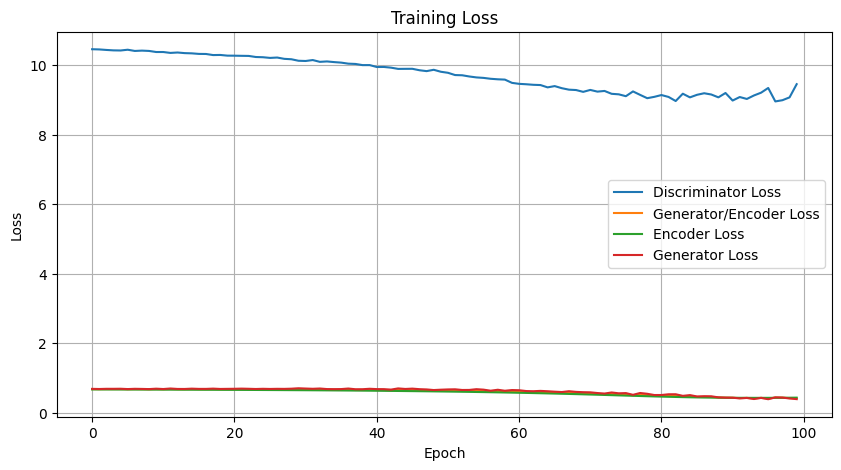

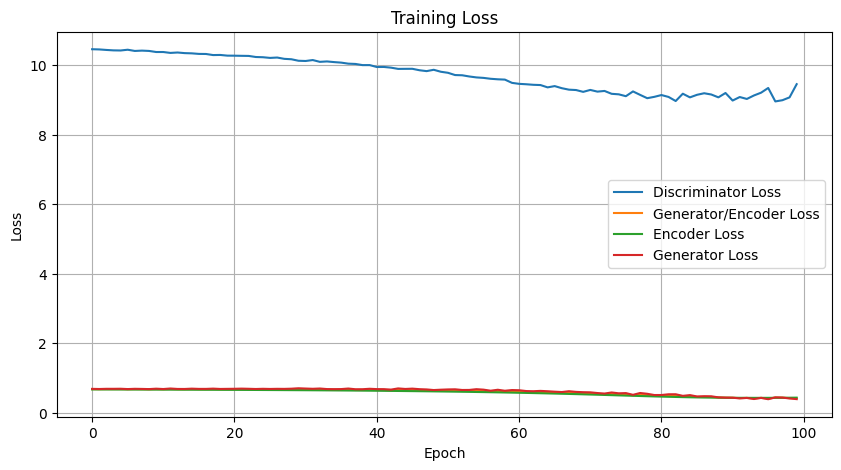

(100, 1)
[[1.6215751]
 [1.6503911]
 [1.7062508]
 [2.317535 ]
 [2.114997 ]
 [1.7723732]
 [1.4552345]
 [2.4536996]
 [1.4695761]
 [1.5944059]
 [2.2421706]
 [1.6310939]
 [2.4294574]
 [2.3291285]
 [1.7772621]
 [1.7838688]
 [1.352535 ]
 [2.1747618]
 [1.8937294]
 [1.855727 ]
 [1.1954695]
 [1.7207592]
 [1.9385973]
 [1.9848858]
 [2.2719135]
 [1.6517017]
 [1.9103785]
 [1.2472221]
 [1.1798215]
 [2.0648613]
 [2.1082134]
 [1.8983147]
 [1.8435307]
 [1.4497907]
 [1.5965028]
 [1.5482526]
 [1.7206273]
 [1.9514153]
 [1.6979525]
 [2.5061672]
 [1.4193716]
 [2.2219062]
 [2.4244127]
 [2.2680464]
 [2.1146634]
 [1.9145718]
 [2.2066512]
 [2.6296902]
 [1.3168514]
 [1.602135 ]
 [1.7115694]
 [2.0189857]
 [1.4187646]
 [2.3504393]
 [2.1820455]
 [1.5689583]
 [2.3180203]
 [1.6089474]
 [1.6516545]
 [1.5471511]
 [2.105756 ]
 [2.222413 ]
 [1.5327398]
 [1.8389018]
 [1.7833189]
 [1.8632898]
 [2.3341963]
 [2.2742467]
 [1.7992096]
 [2.1797616]
 [1.8163021]
 [1.867167 ]
 [1.3769658]
 [1.4492536]
 [2.4303875]
 [1.979886 ]
 [1

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(64, latent_dim)
        )

    def forward(self, x):
        y = self.net(x)
        return y

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, output_dim)
        )

    def forward(self, y):
        z = self.net(y)
        return z

class Discriminator(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Discriminator, self).__init__()
        self.data_net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.latent_net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.joint_net = nn.Sequential(
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()  # (0-1)
        )

    def forward(self, x, z):
        x_out = self.data_net(x)
        z_out = self.latent_net(z)
        joint_input = torch.cat((x_out, z_out), dim=1)
        return self.joint_net(joint_input)

class BiGAN(nn.Module):
    def __init__(self, train_arr,evaluate_arr, latent_dim=100):
        """
        BiGAN 实现

        参数:
        - train_arr: 训练数据，形状为 (n, 17)
        - evaluate_arr: 评估数据，形状为 (n, 17)
        - latent_dim: 潜在空间维度
        - device: 训练设备 (cpu/cuda)
        """
        super(BiGAN, self).__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.scaler = StandardScaler()
        self.train_data = self.scaler.fit_transform(train_arr)
        self.train_data=train_arr
        self.history = {'d_loss': [], 'ge_loss': [],'g_loss': [],'e_loss': []}

        self.input_dim = train_arr.shape[1]  # 输入特征维度
        self.latent_dim = latent_dim

        self.encoder = Encoder(self.input_dim, self.latent_dim)
        self.generator = Generator(self.latent_dim, self.input_dim)
        self.discriminator = Discriminator(self.input_dim, self.latent_dim)

        self.to(self.device)

        self.optimizer_E = optim.Adam(self.encoder.parameters(), lr=0.0003)
        self.optimizer_G = optim.Adam(self.generator.parameters(), lr=0.0002)
        self.optimizer_D = optim.Adam(self.discriminator.parameters(), lr=0.0001)

        self.adversarial_loss = nn.BCELoss()

        train_tensor = torch.FloatTensor(self.train_data)
        self.train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

        # self.evaluate_data = self.scaler.transform(evaluate_arr)
        self.evaluate_data=evaluate_arr
        self.evaluate_tensor = torch.FloatTensor(self.evaluate_data)
        # self.evaluate_loader = DataLoader(TensorDataset(evaluate_tensor), batch_size=128, shuffle=False)

    def forward(self, x):
        """前向传播"""
        z = self.encoder(x)
        x_recon = self.generator(z)
        return z, x_recon

    def discriminate(self, x, z):
        """判别器前向传播"""
        return self.discriminator(x, z)
    def compute_gradient_penalty(self,discriminator, x, Gz, Ex, z):
        """计算梯度惩罚"""
        alpha = torch.rand(x.size(0), 1).to(self.device)
        alpha = alpha.expand_as(x)

    # 创建插值样本
        interpolates = (alpha * x + ((1 - alpha) * Gz)).requires_grad_(True)

    # 创建插值潜在向量
        alpha_z = torch.rand(Ex.size(0), 1).to(self.device)
        alpha_z = alpha_z.expand_as(Ex)
        interpolates_z = (alpha_z * Ex + ((1 - alpha_z) * z)).requires_grad_(True)

    # 计算判别器对插值的输出
        d_interpolates = discriminator(interpolates, interpolates_z)

    # 计算梯度
        gradients = torch.autograd.grad(
            outputs=d_interpolates,
            inputs=[interpolates, interpolates_z],
            grad_outputs=torch.ones_like(d_interpolates),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )

    # 计算梯度范数
        gradients = torch.cat([grad.view(grad.size(0), -1) for grad in gradients], dim=1)
        gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

        return gradient_penalty

    def train_model(self, epochs=100):
        """训练BiGAN模型"""
        self.train()


        for epoch in range(epochs):
            d_loss_sum = 0
            ge_loss_sum = 0
            g_loss_sum = 0
            e_loss_sum = 0

            for i, (x,) in enumerate(self.train_loader):
                x = x.to(self.device)
                batch_size = x.size(0)
                valid = torch.ones(batch_size, 1).to(self.device)*0.9
                fake = torch.zeros(batch_size, 1).to(self.device)*0.1

                # ---------------------
                #  训练判别器
                # ---------------------
                self.optimizer_D.zero_grad()
                Ex = self.encoder(x)
                z = torch.randn(batch_size, self.latent_dim).to(self.device)
                Gz = self.generator(z)

                valid_loss = self.adversarial_loss(self.discriminate(x, Ex.detach()), valid)
                fake_loss = self.adversarial_loss(self.discriminate(Gz.detach(), z), fake)

                lambda_gp = 10  # 梯度惩罚系数
                gradient_penalty = self.compute_gradient_penalty(
                    self.discriminator, x, Gz.detach(), Ex.detach(), z
                )
                # 使用 Wasserstein 损失与梯度惩罚 (WGAN-GP)
                d_loss = (valid_loss + fake_loss) / 2 + lambda_gp * gradient_penalty
                print(valid_loss.item(), fake_loss.item(),gradient_penalty.item())
                # 总判别器损失
                # d_loss = (valid_loss + fake_loss) / 2
                d_loss.backward()
                self.optimizer_D.step()

                # ---------------------
                #  训练生成器和编码器
                # ---------------------
                self.optimizer_G.zero_grad()
                self.optimizer_E.zero_grad()

                # 生成数据对的损失（试图欺骗判别器）
                g_loss = self.adversarial_loss(self.discriminate(Gz, z), valid)

                # 真实数据对的损失（试图欺骗判别器）
                Ex = self.encoder(x)
                e_loss = self.adversarial_loss(self.discriminate(x,Ex), valid)

                # 总生成器和编码器损失
                ge_loss = (g_loss + e_loss) / 2
                # ge_loss.backward()
                g_loss.backward()
                e_loss.backward()

                self.optimizer_G.step()
                self.optimizer_E.step()

                # 记录损失
                d_loss_sum += d_loss.item()
                ge_loss_sum += ge_loss.item()
                e_loss_sum += e_loss.item()
                g_loss_sum+= g_loss.item()

            # 记录平均损失
            self.history['d_loss'].append(d_loss_sum / len(self.train_loader))
            self.history['ge_loss'].append(ge_loss_sum / len(self.train_loader))
            self.history['e_loss'].append(e_loss_sum / len(self.train_loader))
            self.history['g_loss'].append(g_loss_sum / len(self.train_loader))
            # 打印训练进度
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], "
                      f"D Loss: {self.history['d_loss'][-1]:.4f}, "
                      f"G/E Loss: {self.history['ge_loss'][-1]:.4f}")
        return self.history

    def generate_samples(self, n_samples=100):
        """生成样本"""
        self.generator.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, self.latent_dim).to(self.device)
            generated = self.generator(z)
            return generated.cpu().numpy()

    def encode_samples(self, data):
        """编码样本到潜在空间"""
        self.encoder.eval()
        with torch.no_grad():
            data_tensor = torch.FloatTensor(data).to(self.device)
            encoded = self.encoder(data_tensor)
            return encoded.cpu().numpy()

    def reconstruct_samples(self, data):
        """重构样本"""
        self.eval()
        with torch.no_grad():
            data_tensor = torch.FloatTensor(data).to(self.device)
            _, reconstructed = self.forward(data_tensor)
            return reconstructed.cpu().numpy()

    def calculate_reconstruction_error(self, data_loader):
        """计算重构误差"""
        self.eval()
        total_error = 0
        total_samples = 0

        with torch.no_grad():
            for i, (data,) in enumerate(data_loader):
                data = data.to(self.device)
                _, reconstructed = self.forward(data)
                error = torch.mean((reconstructed - data) ** 2, dim=1)
                total_error += torch.sum(error).item()
                total_samples += data.size(0)

        return total_error / total_samples

    def detect_anomalies(self, data, threshold=None):
        """
        检测异常样本

        参数:
        - data: 输入数据
        - threshold: 异常阈值，如果为None则返回异常分数

        返回:
        - 异常标签或异常分数
        """
        self.eval()
        with torch.no_grad():
            data_tensor = torch.FloatTensor(data).to(self.device)
            _, reconstructed = self.forward(data_tensor)

            # 计算重构误差作为异常分数
            recon_error = torch.mean((reconstructed - data_tensor) ** 2, dim=1).cpu().numpy()

            if threshold is not None:
                # 返回异常标签
                return (recon_error > threshold).astype(int)
            else:
                # 返回异常分数
                return recon_error
    def discriminate_evaluation(self):

        self.eval()
        with torch.no_grad():
            self.to('cpu')
            y=self.encoder(self.evaluate_tensor)
            res=self.discriminate(self.evaluate_tensor,y).cpu().numpy()
            res = 3 * res
            print(res.shape)
            print(res)
        return res

    def plot_training_history(self):
        """绘制训练历史"""
        history = self.history
        plt.figure(figsize=(10, 5))
        plt.plot(history['d_loss'], label='Discriminator Loss')
        plt.plot(history['ge_loss'], label='Generator/Encoder Loss')
        plt.plot(history['e_loss'], label='Encoder Loss')
        plt.plot(history['g_loss'], label='Generator Loss')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    def save_model(self, path):
        """保存模型"""
        torch.save({
            'encoder_state_dict': self.encoder.state_dict(),
            'generator_state_dict': self.generator.state_dict(),
            'discriminator_state_dict': self.discriminator.state_dict(),
            'scaler': self.scaler,
            'history': self.history
        }, path)

    def load_model(self, path):
        """加载模型"""
        checkpoint = torch.load(path, map_location=self.device,weights_only=False)
        self.encoder.load_state_dict(checkpoint['encoder_state_dict'])
        self.generator.load_state_dict(checkpoint['generator_state_dict'])
        self.discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        self.scaler = checkpoint['scaler']
        self.history = checkpoint['history']


# 使用示例
if __name__ == "__main__":
    # 假设我们有训练、测试和评估数据
    # n_samples = 107230
    n_samples = 10
    train_arr = np.random.randn(n_samples, 17)
    # evaluate_arr = np.random.randn(39517450, 17)
    evaluate_arr = np.random.randn(100, 17)
    bigan = BiGAN(train_arr, evaluate_arr, latent_dim=50)
    history = bigan.train_model(epochs=100)
    bigan.plot_training_history()

    # res=bigan.discriminate_evaluation()
    # print(res)
    bigan.save_model("1.pth")
    bigan.load_model(path='1.pth')
    bigan.plot_training_history()
    bigan.discriminate_evaluation()


In [4]:
import torch

# 设置设备（优先使用 GPU）
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 如果有多块 GPU，可以指定索引（例如使用第二块 GPU，索引从0开始）
if torch.cuda.device_count() > 1:
    device = torch.device("cuda:1")  # 使用第二块 GPU
# 1. 检查当前默认张量设备（注意：这仅影响新创建的张量）
print(f"Default tensor device: {torch.randn(1).device}")

# 4. 输出当前 GPU 信息
if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU index: {torch.cuda.current_device()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Using device: cuda:0
Default tensor device: cpu
Number of GPUs: 1
Current GPU index: 0
Current GPU name: NVIDIA GeForce RTX 3090


In [34]:
def MSE(train_arr,evaluate_arr,type:str):
    std_sample=np.mean(train_arr,axis=0)
    print(std_sample)
    distances = np.linalg.norm(evaluate_arr - std_sample, axis=1)
    distances=(distances-np.min(distances))/(np.max(distances)-np.min(distances))
    distances = 3-3*distances
    return distances
train_arr=np.random.rand(100,17)
evaluate_arr=np.random.randn(100,17)
MSE(train_arr,evaluate_arr,'train')

[0.49128633 0.50496464 0.55096766 0.45935178 0.50743221 0.49560287
 0.46504399 0.51174193 0.45685605 0.53438229 0.49567571 0.4920121
 0.47676087 0.51274504 0.50737187 0.50278254 0.49362089]
[1.85740557 1.83092881 1.06344347 0.91909415 2.39646299 1.78507869
 1.53856053 1.78760249 1.74908625 2.29454289 2.35931015 2.23231008
 1.891639   2.08189254 1.62969504 2.03436282 2.49602522 0.99521119
 1.88937283 1.36844591 1.81020893 1.24207582 0.06074015 2.21043078
 1.60110879 2.39206756 2.24693574 1.03945297 1.77867426 1.99011022
 2.16281232 0.99987822 2.41695991 0.84093239 1.77151463 0.94861653
 0.42924467 0.96156848 2.17900234 2.00351935 2.01469788 2.38876749
 1.75311046 1.85257139 1.45294322 0.93357564 2.25072671 1.96603224
 2.48609194 2.25747644 2.32063663 2.73168607 1.74038988 2.51015317
 3.         1.49001189 1.48566713 2.22237475 1.65490324 1.69189397
 2.32086674 1.56138779 0.77742172 2.53853128 1.56597934 2.7881021
 1.86218853 1.62424109 2.34570178 1.90420473 1.4881409  2.08563184
 2.9618

In [67]:
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, output_dim),
            nn.Tanh()
        )
    def forward(self, y):
        return self.model(y)

class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, latent_dim)
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Discriminator, self).__init__()
        # 处理输入数据的路径
        self.data_path = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
        )

        # 处理潜在向量的路径
        self.latent_path = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),
        )

        # 联合处理
        self.joint = nn.Sequential(
            nn.Linear(64, 32),  # 32+32=64
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x, z):
        x_out = self.data_path(x)
        z_out = self.latent_path(z)
        joint_input = torch.cat((x_out, z_out), dim=1)
        return self.joint(joint_input)

class BiGAN(nn.Module):
    def __init__(self, train_arr,Type,latent_dim=100):
        """
        BiGAN 实现

        参数:
        - train_arr: 训练数据，形状为 (n, 17)
        - evaluate_arr: 评估数据，形状为 (n, 17)
        - latent_dim: 潜在空间维度
        - device: 训练设备 (cpu/cuda)
        """
        super(BiGAN, self).__init__()
        self.Type=Type
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.history = {'D_loss': [], 'GE_loss': [], 'G_loss': [], 'E_loss': []}
        self.input_dim = train_arr.shape[1]
        self.latent_dim = latent_dim
        self.encoder = Encoder(self.input_dim, self.latent_dim)
        self.generator = Generator(self.latent_dim, self.input_dim)
        self.discriminator = Discriminator(self.input_dim, self.latent_dim)

        self.optimizer_E = optim.Adam(self.encoder.parameters(),lr=0.0003)
        self.optimizer_G = optim.Adam(self.generator.parameters(), lr=0.0002)
        self.optimizer_D = optim.Adam(self.discriminator.parameters(), lr=0.0002)
        self.adversarial_loss = nn.BCELoss()

        if self.Type=='RAW':
            self.scaler = StandardScaler()
            self.train_data = self.scaler.fit_transform(train_arr)
            train_tensor = torch.FloatTensor(self.train_data)
        else:
            train_tensor = torch.FloatTensor(train_arr)
        self.train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64)
        self.to(self.device)

    def forward(self, x):
        """前向传播"""
        z = self.encoder(x)
        x_recon = self.generator(z)
        return z, x_recon

    def discriminate(self, x, z):
        """判别器前向传播"""
        return self.discriminator(x, z)

    def compute_gradient_penalty(self, discriminator, x, Gz, Ex, z):
        """计算梯度惩罚"""
        alpha = torch.rand(x.size(0), 1).to(self.device)
        alpha = alpha.expand_as(x)

        # 创建插值样本
        interpolates = (alpha * x + ((1 - alpha) * Gz)).requires_grad_(True)

        # 创建插值潜在向量
        alpha_z = torch.rand(Ex.size(0), 1).to(self.device)
        alpha_z = alpha_z.expand_as(Ex)
        interpolates_z = (alpha_z * Ex + ((1 - alpha_z) * z)).requires_grad_(True)

        # 计算判别器对插值的输出
        d_interpolates = discriminator(interpolates, interpolates_z)

        # 计算梯度
        gradients = torch.autograd.grad(
            outputs=d_interpolates,
            inputs=[interpolates, interpolates_z],
            grad_outputs=torch.ones_like(d_interpolates),
            create_graph=True,
            retain_graph=True,
            only_inputs=True
        )

        # 计算梯度范数
        gradients = torch.cat([grad.view(grad.size(0), -1) for grad in gradients], dim=1)
        gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

        return gradient_penalty

    def train_model(self, epochs=100):
        """训练BiGAN模型"""
        self.train()

        judge=[]
        l=len(self.train_loader)
        lambda_gp = 10  # 梯度惩罚系数
        for epoch in range(epochs):
            d_loss_sum,ge_loss_sum,g_loss_sum,e_loss_sum= 0,0,0,0
            for i, (x,) in enumerate(self.train_loader):
                self.optimizer_D.zero_grad()
                x = x.to(self.device)
                batch_size = x.size(0)
                Ex = self.encoder(x)
                z = torch.randn(batch_size, self.latent_dim).to(self.device)
                Gz = self.generator(z)
                gradient_penalty = self.compute_gradient_penalty(
                self.discriminator, x, Gz.detach(), Ex.detach(), z)
                batch_size = x.size(0)
                valid = torch.ones(batch_size, 1).to(self.device)
                fake = torch.zeros(batch_size, 1).to(self.device)
                valid_loss = self.adversarial_loss(self.discriminate(x, Ex.detach()), valid)
                fake_loss = self.adversarial_loss(self.discriminate(Gz.detach(), z), fake)
                # 使用 Wasserstein 损失与梯度惩罚 (WGAN-GP)
                # d_loss =torch.mean(self.discriminate(Gz.detach(), z)-self.discriminate(x, Ex.detach())+ lambda_gp * gradient_penalty)
                d_loss =(valid_loss + fake_loss) / 2 + lambda_gp * gradient_penalty
                # d_loss =(valid_loss + fake_loss) / 2
                d_loss.backward()
                self.optimizer_D.step()

            #  训练生成器和编码器
                self.optimizer_G.zero_grad()
                self.optimizer_E.zero_grad()
                # g_loss = torch.mean(self.adversarial_loss(self.discriminate(Gz, z), valid))
                # e_loss = torch.mean(self.adversarial_loss(self.discriminate(x, Ex), valid))
                g_loss=torch.mean(-1*(self.discriminate(Gz.detach(), z)))
                e_loss=torch.mean(-1*(self.discriminate(x, Ex.detach())))
                ge_loss = (g_loss + e_loss) / 2
                ge_loss.backward()
                self.optimizer_G.step()
                self.optimizer_E.step()
                # print(d_loss.item(),g_loss.item(),e_loss.item())
                d_loss_sum += d_loss.item()
                ge_loss_sum += ge_loss.item()
                e_loss_sum += e_loss.item()
                g_loss_sum+= g_loss.item()

            # eopch过后,记录平均损失
            self.history['D_loss'].append(d_loss_sum/l)
            self.history['GE_loss'].append(ge_loss_sum/l)
            self.history['G_loss'].append(g_loss_sum/l)
            self.history['E_loss'].append(e_loss_sum/l)
            judge.append(abs(ge_loss.item()-d_loss.item()))
            # 打印训练进度
            if (epoch + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], "
                      f"D Loss: {self.history['D_loss'][-1]:.4f}, "
                      f"G/E Loss: {self.history['GE_loss'][-1]:.4f}, "
                      f"G Loss: {self.history['G_loss'][-1]:.4f}, "
                      f"E Loss: {self.history['E_loss'][-1]:.4f}")
                print(f'最小差距：{min(judge)}')
                self.save_model(path=f'./res/models/{self.Type}-GAN_{epoch}.pth')
                # self.plot_training_history()

        return self.history

    def discriminate_evaluation(self,evaluate_arr):
        scaler=StandardScaler()
        scaler.fit_transform(evaluate_arr)
        evaluate_data = self.scaler.transform(evaluate_arr)
        evaluate_tensor = torch.FloatTensor(evaluate_data)
        self.eval()
        with torch.no_grad():
            self.to('cpu')
            y=self.encoder(evaluate_tensor)
            res=self.discriminate(evaluate_tensor,y).cpu().numpy()
            # res=3*(res-np.min(res))/(np.max(res)-np.min(res))  取消sigmoid
            # res = 3 *(1 / (1 + np.exp(-res)))
            res=3*res
            print(res.shape)
            print(res)
            sts = res_sts(res, np.array([0, 0.25, 0.5, 0.75, 1]), self.Type + '-BiGAN')
            if sts!=None:
                print("分类阈值:", sts['thresholds'])
                print("各类别像素数量:", sts['class_counts'])
                print("各类别百分比:", sts['percentages'])
            else:
                print('sts_error,!❌None')
            res = np.array(res).reshape(4909, 8050)
            construct_map(res, transform=transform, crs=crs, height=height, width=width,
                          tif_path=res_folder + '/' + self.Type + '-res_BiGAN.tif')
        return res

    def plot_training_history(self):
        """绘制训练历史"""
        history = self.history
        plt.figure(figsize=(10, 5))
        plt.plot(history['D_loss'], label='Discriminator Loss')
        # plt.plot(history['GE_loss'], label='Generator/Encoder Loss')
        plt.plot(history['E_loss'], label='Encoder Loss')
        plt.plot(history['G_loss'], label='Generator Loss')
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    def save_model(self, path):
        """保存模型"""
        torch.save({
            'encoder_state_dict': self.encoder.state_dict(),
            'generator_state_dict': self.generator.state_dict(),
            'discriminator_state_dict': self.discriminator.state_dict(),
            'history': self.history
        }, path)

    def load_model(self, path):
        """加载模型"""
        checkpoint = torch.load(path, map_location=self.device,weights_only=False)
        self.encoder.load_state_dict(checkpoint['encoder_state_dict'])
        self.generator.load_state_dict(checkpoint['generator_state_dict'])
        self.discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        self.history = checkpoint['history']
if __name__ == "__main__":
    # 假设我们有训练、测试和评估数据
    # n_samples = 107230
    n_samples = 1000
    train_arr = np.random.randn(n_samples, 17)
    # evaluate_arr = np.random.randn(39517450, 17)
    evaluate_arr = np.random.randn(100, 17)
    bigan = BiGAN(train_arr,latent_dim=51,Type='CF')
    history = bigan.train_model(epochs=1000)
    bigan.plot_training_history()

    # res=bigan.discriminate_evaluation()
    # print(res)
    # bigan.save_model("1.pth")
    # bigan.load_model(path='1.pth')
    # bigan.plot_training_history()
    # bigan.discriminate_evaluation()

Epoch [10/1000], D Loss: 5.5401, G/E Loss: -0.4965, G Loss: -0.4668, E Loss: -0.5263
最小差距：5.75567701458931
Epoch [20/1000], D Loss: 3.8517, G/E Loss: -0.5023, G Loss: -0.4124, E Loss: -0.5923
最小差距：3.8280397057533264
Epoch [30/1000], D Loss: 3.8893, G/E Loss: -0.5012, G Loss: -0.3975, E Loss: -0.6048
最小差距：3.8280397057533264
Epoch [40/1000], D Loss: 3.8286, G/E Loss: -0.5059, G Loss: -0.4068, E Loss: -0.6051
最小差距：3.6496378779411316
Epoch [50/1000], D Loss: 3.5577, G/E Loss: -0.4800, G Loss: -0.3697, E Loss: -0.5904
最小差距：3.5323901772499084
Epoch [60/1000], D Loss: 3.3553, G/E Loss: -0.4998, G Loss: -0.3943, E Loss: -0.6053
最小差距：3.4163258969783783
Epoch [70/1000], D Loss: 3.2050, G/E Loss: -0.5022, G Loss: -0.3805, E Loss: -0.6238
最小差距：3.0473920106887817
Epoch [80/1000], D Loss: 3.2571, G/E Loss: -0.5065, G Loss: -0.3757, E Loss: -0.6372
最小差距：3.0473920106887817
Epoch [90/1000], D Loss: 3.0771, G/E Loss: -0.5184, G Loss: -0.3931, E Loss: -0.6437
最小差距：3.015890896320343
Epoch [100/1000], D Lo

KeyboardInterrupt: 

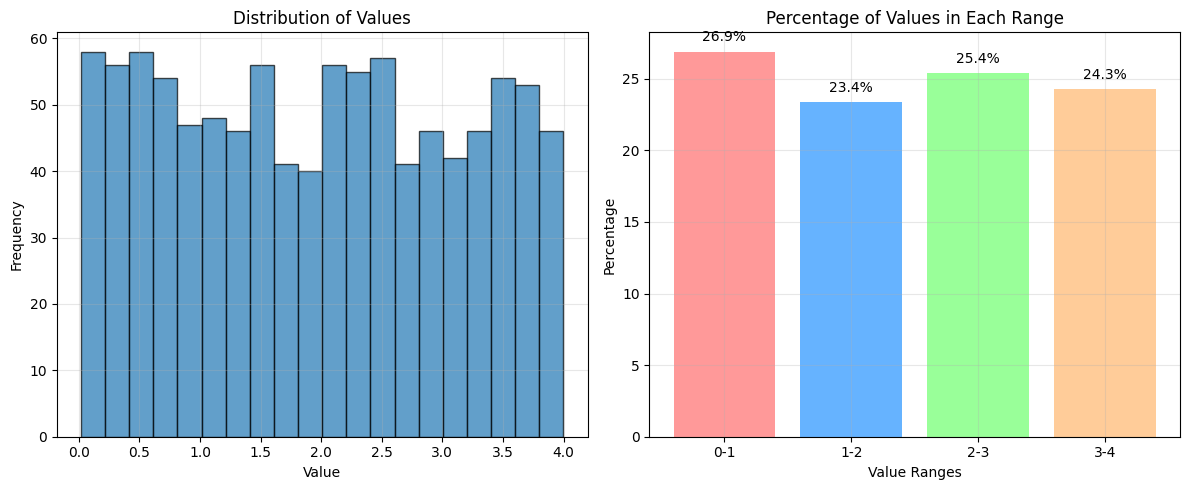

Counts in each range:
Range 0-1: 269 elements
Range 1-2: 234 elements
Range 2-3: 254 elements
Range 3-4: 243 elements

Percentages:
Range 0-1: 26.90%
Range 1-2: 23.40%
Range 2-3: 25.40%
Range 3-4: 24.30%

Total elements: 1000


In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
map_arr = np.random.uniform(0, 4, 1000)

# Count elements in each range
class_counts = np.array([
    np.sum((0 <= map_arr) & (map_arr < 1)),
    np.sum((1 <= map_arr) & (map_arr < 2)),
    np.sum((2 <= map_arr) & (map_arr < 3)),
    np.sum((3 <= map_arr) & (map_arr <= 4))
])

# Calculate percentages
percentages = class_counts / len(map_arr) * 100

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of the data
ax1.hist(map_arr, bins=20, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Values')
ax1.grid(True, alpha=0.3)

# Bar chart of percentages
ranges = ['0-1', '1-2', '2-3', '3-4']
bars = ax2.bar(ranges, percentages, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax2.set_xlabel('Value Ranges')
ax2.set_ylabel('Percentage')
ax2.set_title('Percentage of Values in Each Range')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, percentage in zip(bars, percentages):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the results
print("Counts in each range:")
for i, (rng, count) in enumerate(zip(ranges, class_counts)):
    print(f"Range {rng}: {count} elements")

print("\nPercentages:")
for i, (rng, percentage) in enumerate(zip(ranges, percentages)):
    print(f"Range {rng}: {percentage:.2f}%")

print(f"\nTotal elements: {len(map_arr)}")

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# bottleneck hidden layer
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            # 引入dropout，随机0.2的神经元输出清零，模拟随机连接
            nn.Linear(input_dim, 128),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, encoding_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, input_dim),
            nn.Tanh()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

class RandNetEnsemble(nn.Module):
    def __init__(self, n_estimators, input_dim, encoding_dim):
        super(RandNetEnsemble, self).__init__()
        self.n_estimators = n_estimators
        self.autoencoders = nn.ModuleList()
        for _ in range(n_estimators):
            self.autoencoders.append(Autoencoder(input_dim, encoding_dim))

    def forward(self, x):
        all_reconstructions = []
        for ae in self.autoencoders:
            # 此处标准化一下所有的ae(x)
            print(f'x:{x.shape}')
            print(f'ae(x): {ae(x).shape}')
            x=ae(x)
            all_reconstructions.append((x-x.mean())/x.std())
        # 选择中位数作为输出
        all_reconstructions=torch.stack(all_reconstructions, dim=0)
        print(f'torch.median(all_reconstructions, dim=0):{torch.median(all_reconstructions, dim=0)[0].shape}')
        return torch.median(all_reconstructions, dim=0)[0]

    def get_ensemble_reconstruction_error(self, x, criterion=nn.MSELoss(reduction='none')):
        reconstructions = self.forward(x) # (n_estimators, input_dim)
        print(f'reconstructions: {reconstructions.shape}')
        error = criterion(reconstructions, x)
        return error.float()

def train_randnet(ensemble, train_arr, num_epochs_per_ae, learning_rate):
    """训练RandNet集成模型"""
    optimizer_list = [optim.Adam(ae.parameters(), lr=learning_rate) for ae in ensemble.autoencoders]
    criterion = nn.MSELoss()
    train_arr=train_arr
    train_loader = torch.utils.data.DataLoader(train_arr, batch_size=64, shuffle=True)
    for ae_idx, (autoencoder, optimizer) in enumerate(zip(ensemble.autoencoders, optimizer_list)):
        print(f"Training Autoencoder {ae_idx+1}/{ensemble.n_estimators}")
        autoencoder.train()

        for epoch in range(num_epochs_per_ae):
            total_loss = 0
            for batch_idx, data in enumerate(train_loader):
                data = data.view(data.size(0), -1) # 展平数据
                optimizer.zero_grad()
                output = autoencoder(data)
                loss = criterion(output, data)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                print(f'data: {data.size()}, output: {output.size()}, loss: {loss.item()}')

            print(f"Epoch {epoch+1}/{num_epochs_per_ae}, Loss: {total_loss / (batch_idx+1):.6f}")
        print("---")
def evaluate_randnet(ensemble, evaluate_arr):
    ensemble.eval()
    all_scores = []
    with torch.no_grad():
        for data in evaluate_arr:
            anomaly_scores = ensemble.get_ensemble_reconstruction_error(data)
            all_scores.append(anomaly_scores)
    # print(all_scores)
    print(len(all_scores))
    return  np.array(all_scores)


train_arr,evaluate_arr =torch.randn(1000,17), torch.randn(1000,17)
Randnet=RandNetEnsemble(n_estimators=100, input_dim=17,encoding_dim=32)
train_randnet(Randnet, train_arr,1,0.0001)
anomaly_scores= evaluate_randnet(Randnet, evaluate_arr)
# 后续可以使用ROC曲线、Precision-Recall曲线或特定阈值来计算F1分数等指标来评估模型性能。
# 例如，使用sklearn.metrics.roc_auc_score
# from sklearn.metrics import roc_auc_score
# auc = roc_auc_score(true_labels, anomaly_scores)

Training Autoencoder 1/100
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 0.9849829077720642
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 0.9432103633880615
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 1.0234804153442383
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 0.9919121861457825
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 1.0554149150848389
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 0.9654644131660461
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 1.0093971490859985
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 1.0023744106292725
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 1.0444244146347046
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 0.911098301410675
data: torch.Size([64, 17]), output: torch.Size([64, 17]), loss: 1.0507473945617676
data: torch.Size([64, 17]), output: torch.Size([64, 17]), los

成功读取文件: res\res\cf-L2_Norm.tif EPSG Code: EPSG:32643  Affine Transform: | 30.00, 0.00, 387486.72|
| 0.00,-30.00, 4370826.48|
| 0.00, 0.00, 1.00|
成功读取文件: res\res\CF-res_BiGAN-50.tif EPSG Code: EPSG:32643  Affine Transform: | 30.00, 0.00, 387486.72|
| 0.00,-30.00, 4370826.48|
| 0.00, 0.00, 1.00|
成功读取文件: res\res\CF-res_isoforest.tif EPSG Code: EPSG:32643  Affine Transform: | 30.00, 0.00, 387486.72|
| 0.00,-30.00, 4370826.48|
| 0.00, 0.00, 1.00|
成功读取文件: res\res\CF-res_oneclasssvm.tif EPSG Code: EPSG:32643  Affine Transform: | 30.00, 0.00, 387486.72|
| 0.00,-30.00, 4370826.48|
| 0.00, 0.00, 1.00|
成功读取文件: res\res\RAW-L2_Norm.tif EPSG Code: EPSG:32643  Affine Transform: | 30.00, 0.00, 387486.72|
| 0.00,-30.00, 4370826.48|
| 0.00, 0.00, 1.00|
成功读取文件: res\res\RAW-res_BiGAN_359.tif EPSG Code: EPSG:32643  Affine Transform: | 30.00, 0.00, 387486.72|
| 0.00,-30.00, 4370826.48|
| 0.00, 0.00, 1.00|
成功读取文件: res\res\RAW-res_isoforest.tif EPSG Code: EPSG:32643  Affine Transform: | 30.00, 0.00, 387486.72

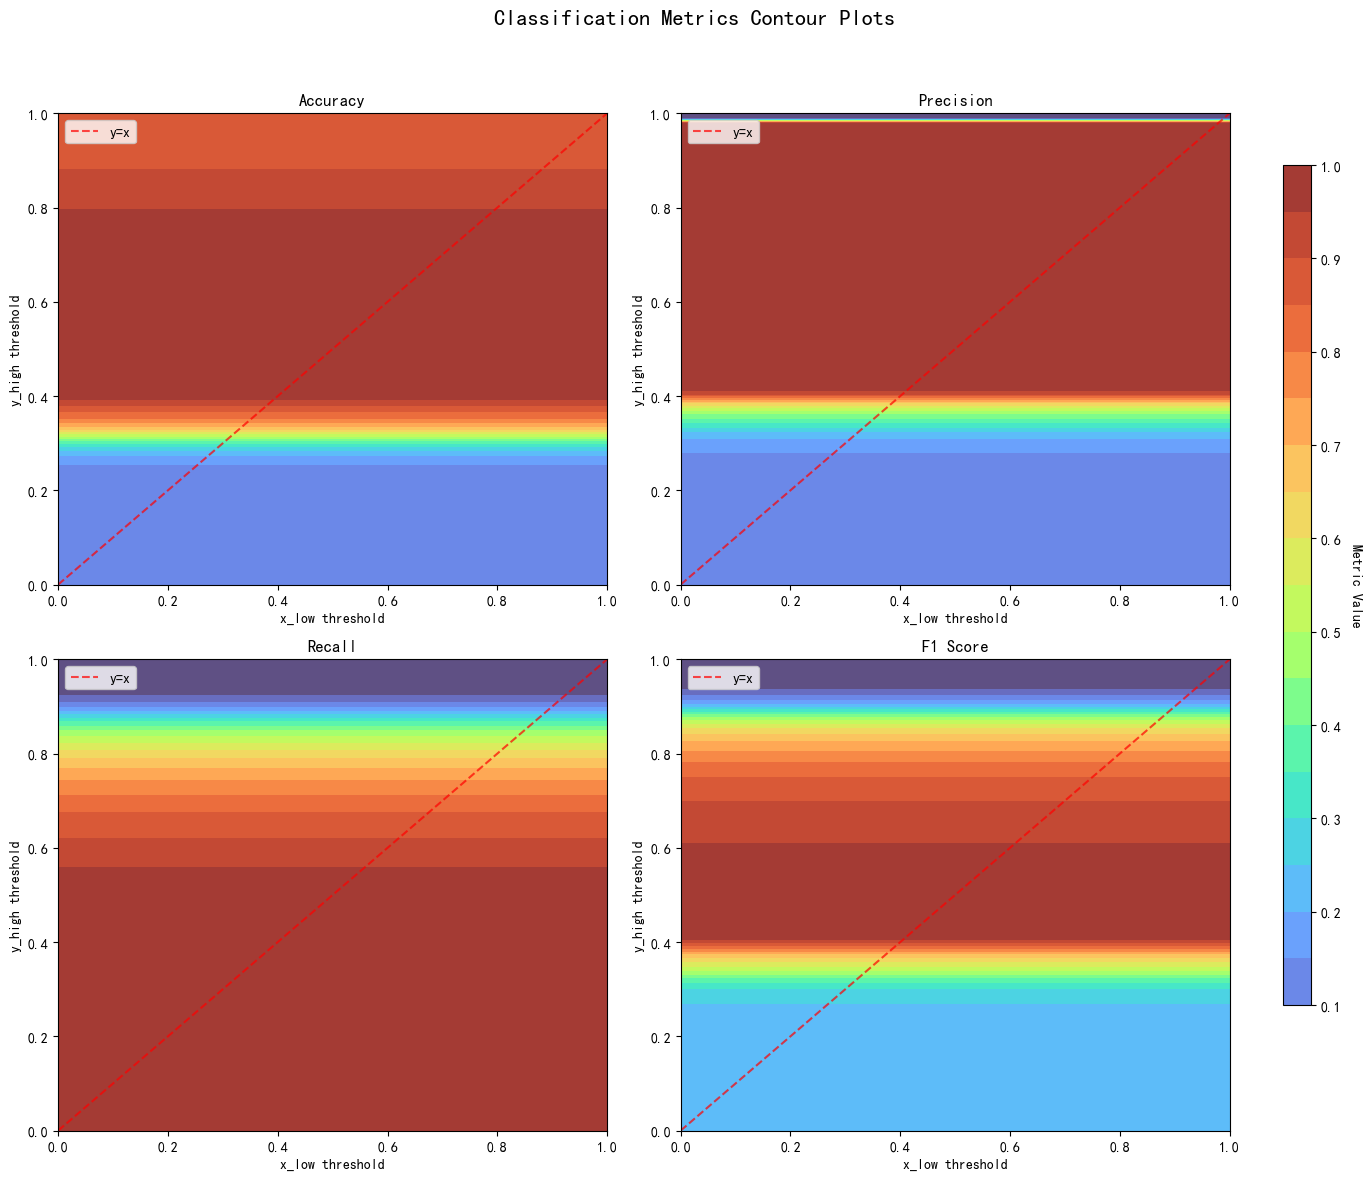

1的最小/大值：9.243456665007864e-34    3.841435432434082
tp:95338, fp:1073, tn:644279, fn:11892
accuracy:0.9827726413865865, precision:0.9888705645621351, recall:0.8890982001305605, f1:0.9363340388232233, roc_auc:0.9991803246843545, score1:8.39, score2:8.80 


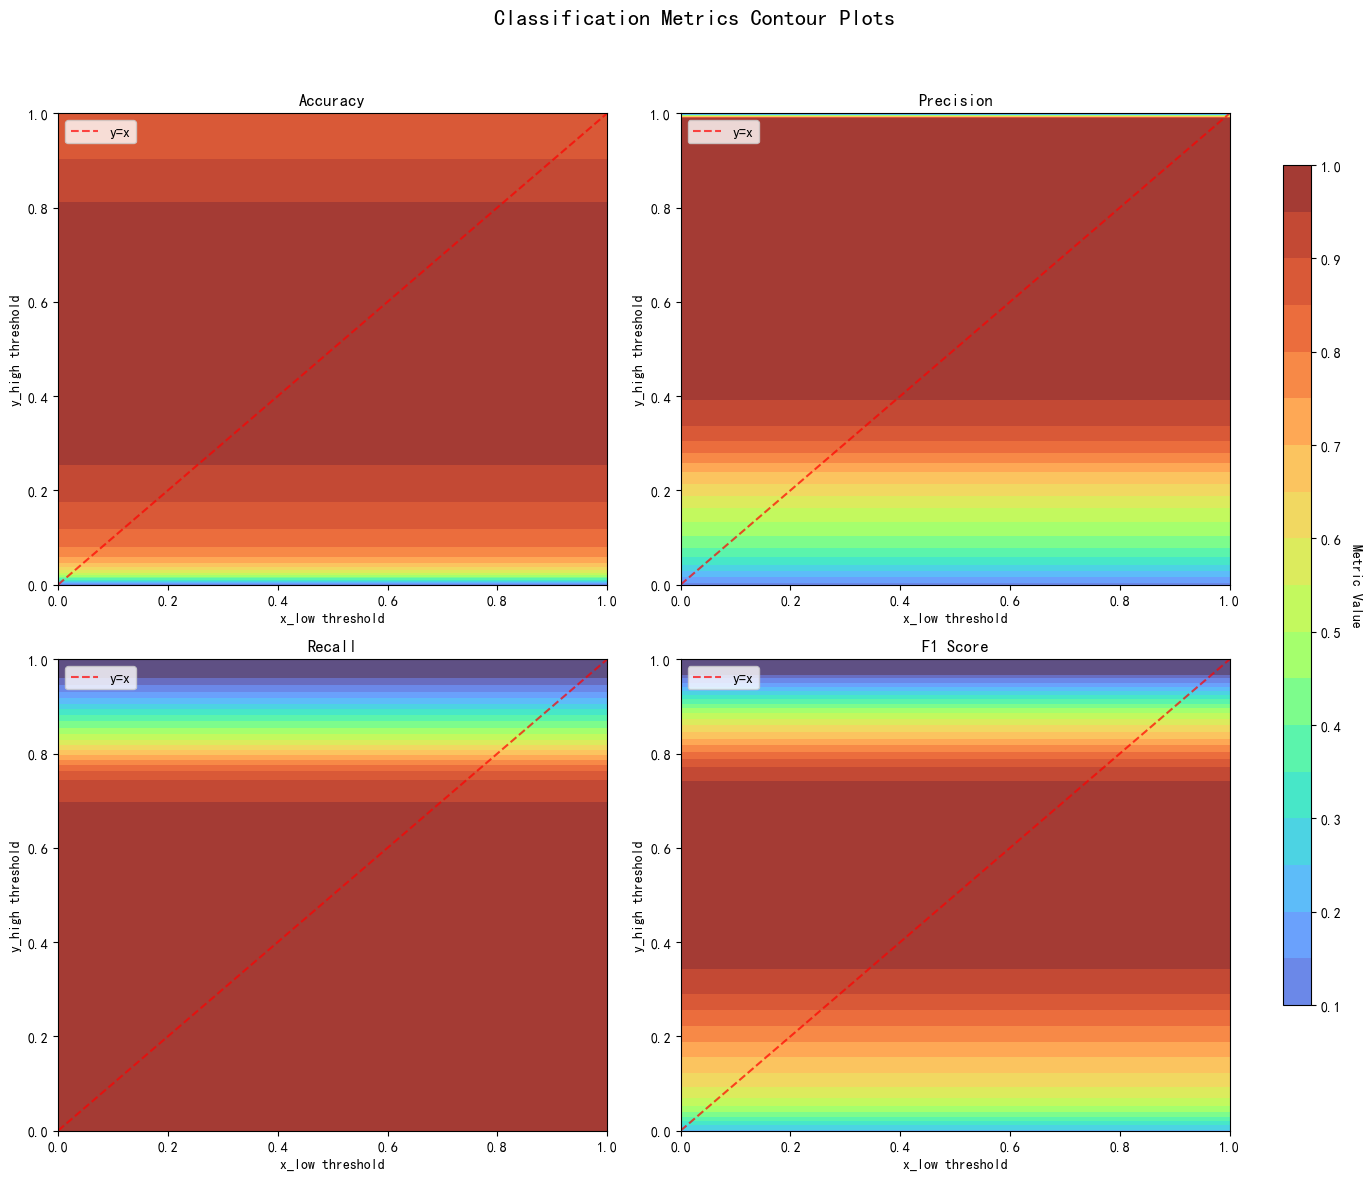

2的最小/大值：0.7941169142723083    1.975554347038269
tp:66782, fp:6782, tn:3505, fn:40448
accuracy:0.5981007003242084, precision:0.9078081670382252, recall:0.6227921290683577, f1:0.7387634545394205, roc_auc:0.992336057601874, score1:7.79, score2:4.01 


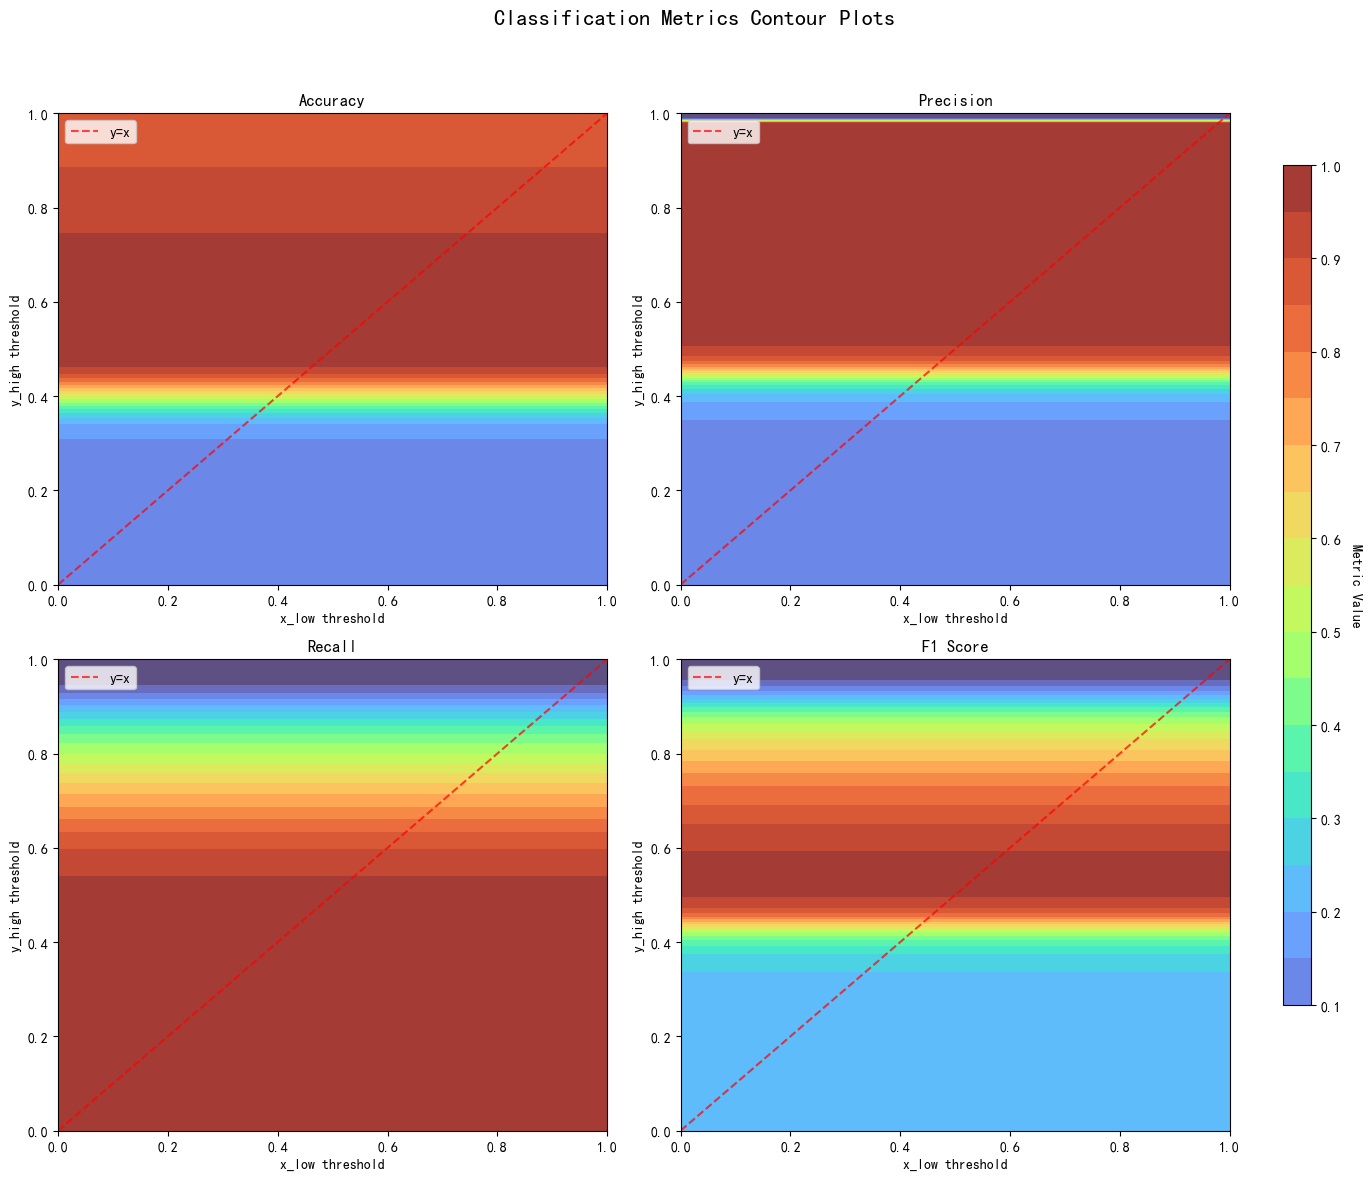

3的最小/大值：9.683943790150806e-05    4.0
tp:1253, fp:82, tn:658388, fn:105977
accuracy:0.8614875277523835, precision:0.9385767790262173, recall:0.011685162734309428, f1:0.02308294570073228, roc_auc:0.9993493625853405, score1:5.92, score2:6.94 


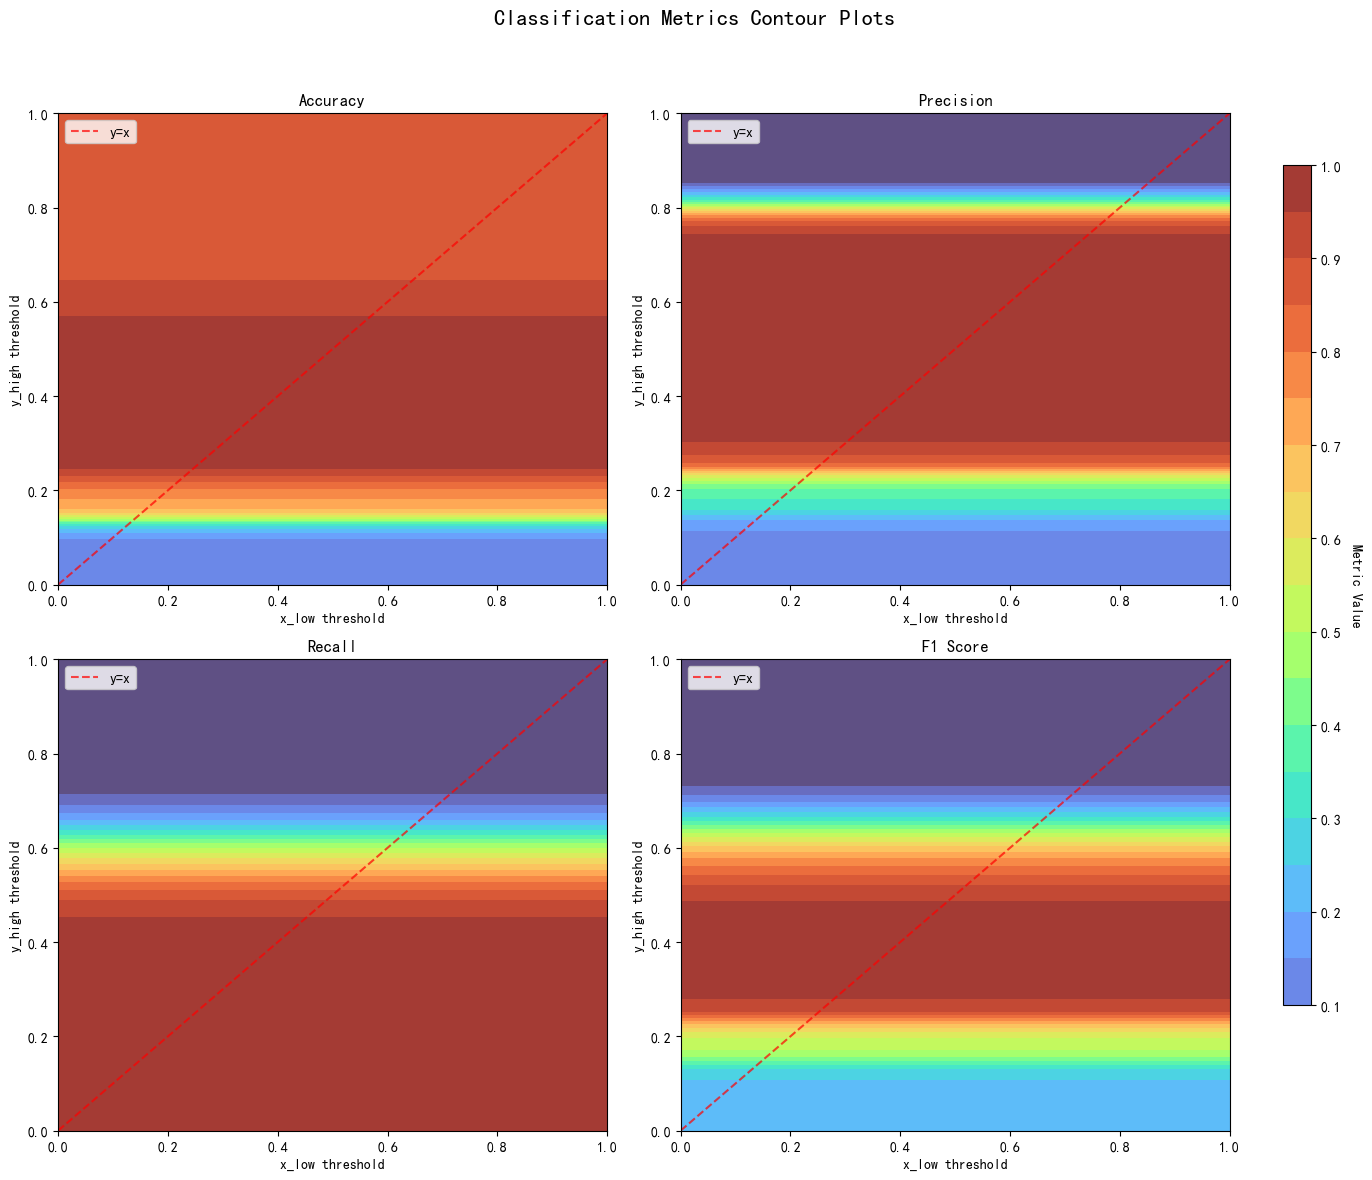

4的最小/大值：0.0021636486053466797    4.0
tp:29506, fp:681938, tn:2981, fn:77724
accuracy:0.04101122389853424, precision:0.041473397765670945, recall:0.2751655320339457, f1:0.07208241619985489, roc_auc:0.11173949191926326, score1:6.83, score2:1.37 


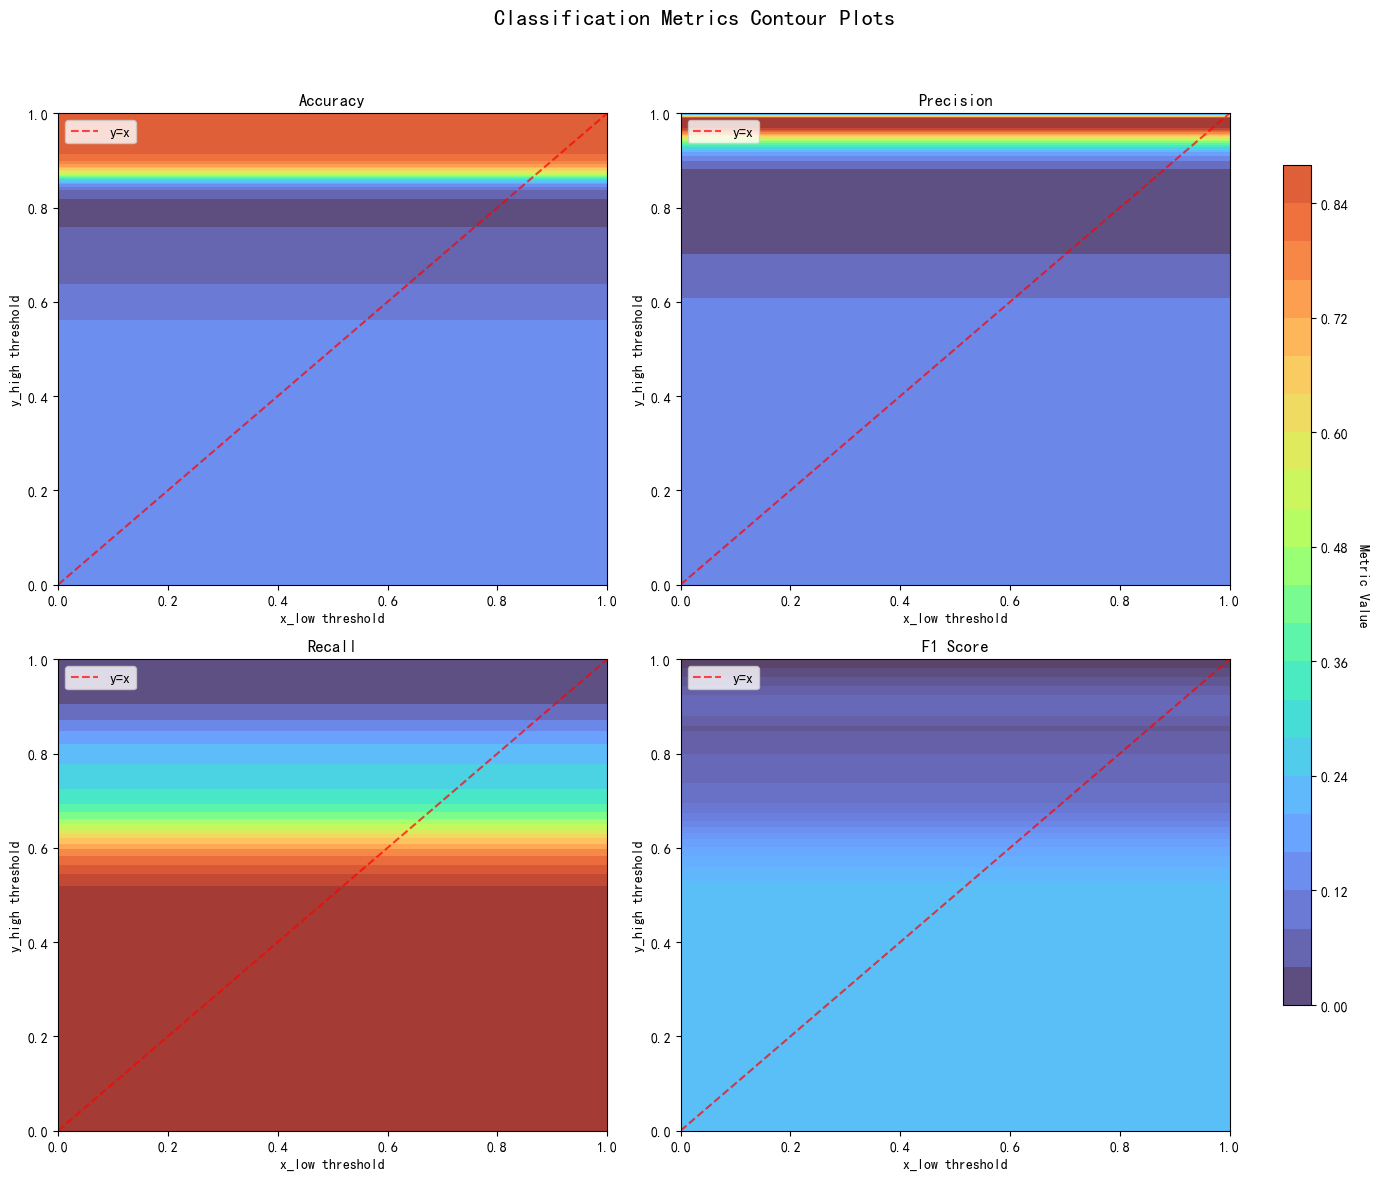

5的最小/大值：1.218809607393339e-38    3.9999256134033203
tp:4390, fp:75785, tn:410301, fn:102840
accuracy:0.6989378341389748, precision:0.054755222949797316, recall:0.040940035437843886, f1:0.046850404204797094, roc_auc:0.21900358483463953, score1:1.28, score2:6.32 


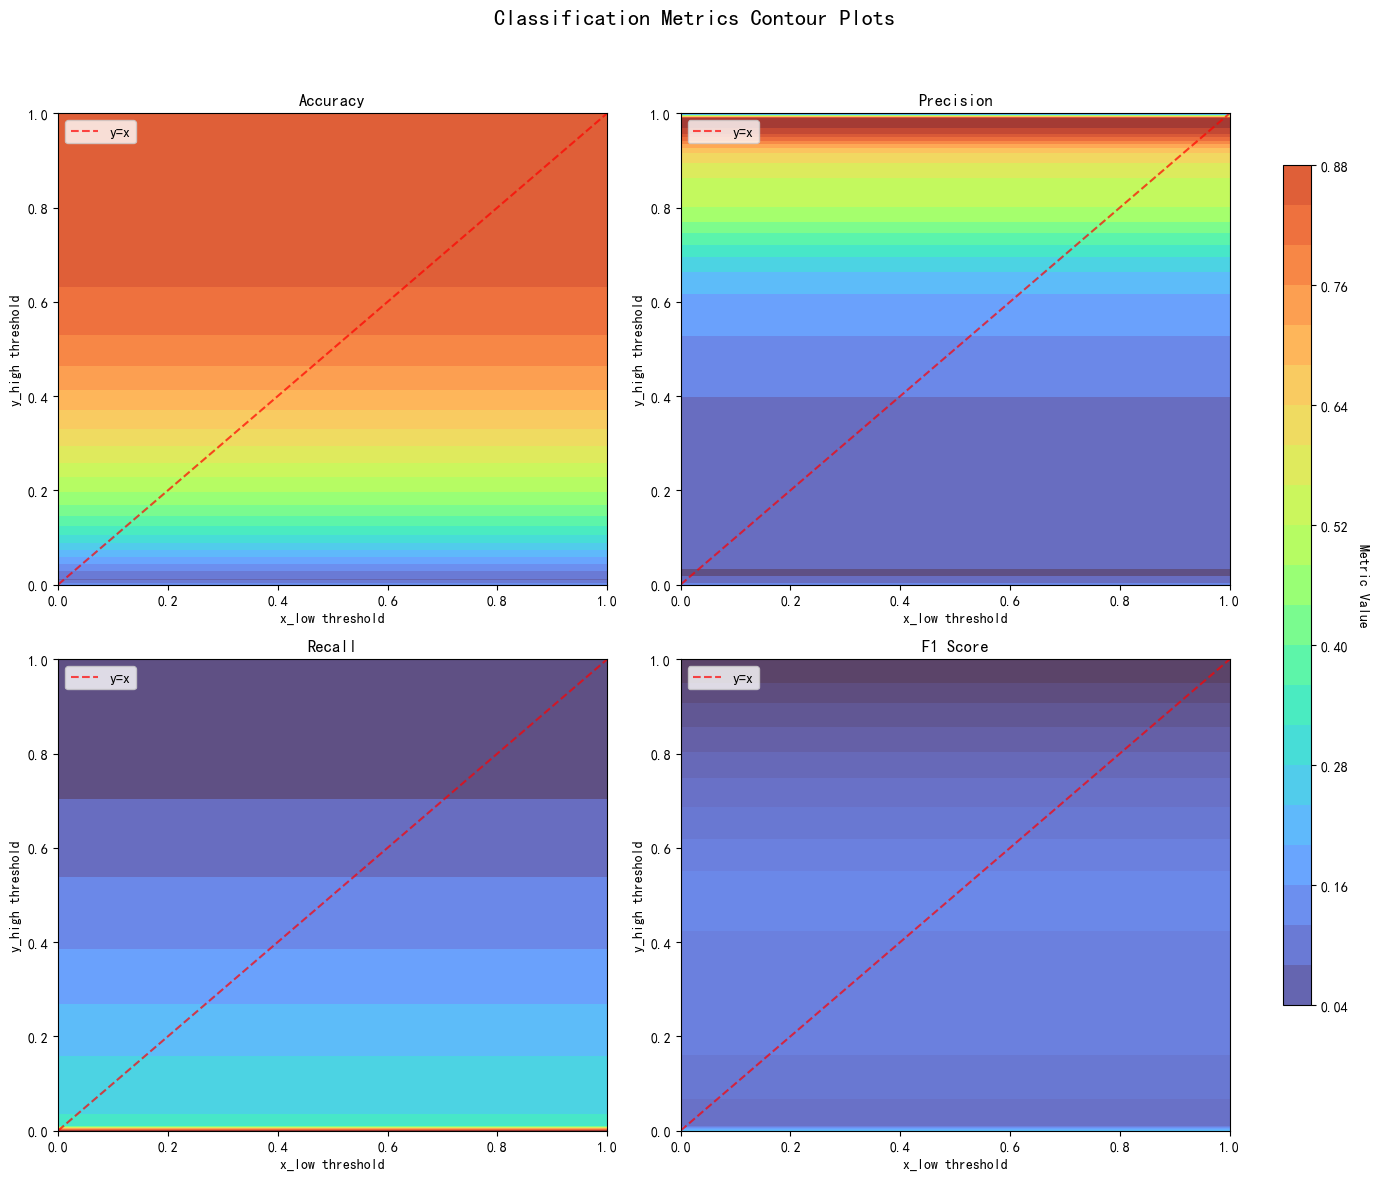

6的最小/大值：0.8804711699485779    2.030837059020996
tp:68132, fp:16, tn:6933, fn:39098
accuracy:0.65743262771613, precision:0.9997652168809062, recall:0.6353818893966241, f1:0.7769731665317201, roc_auc:0.9949764159879939, score1:7.75, score2:4.53 


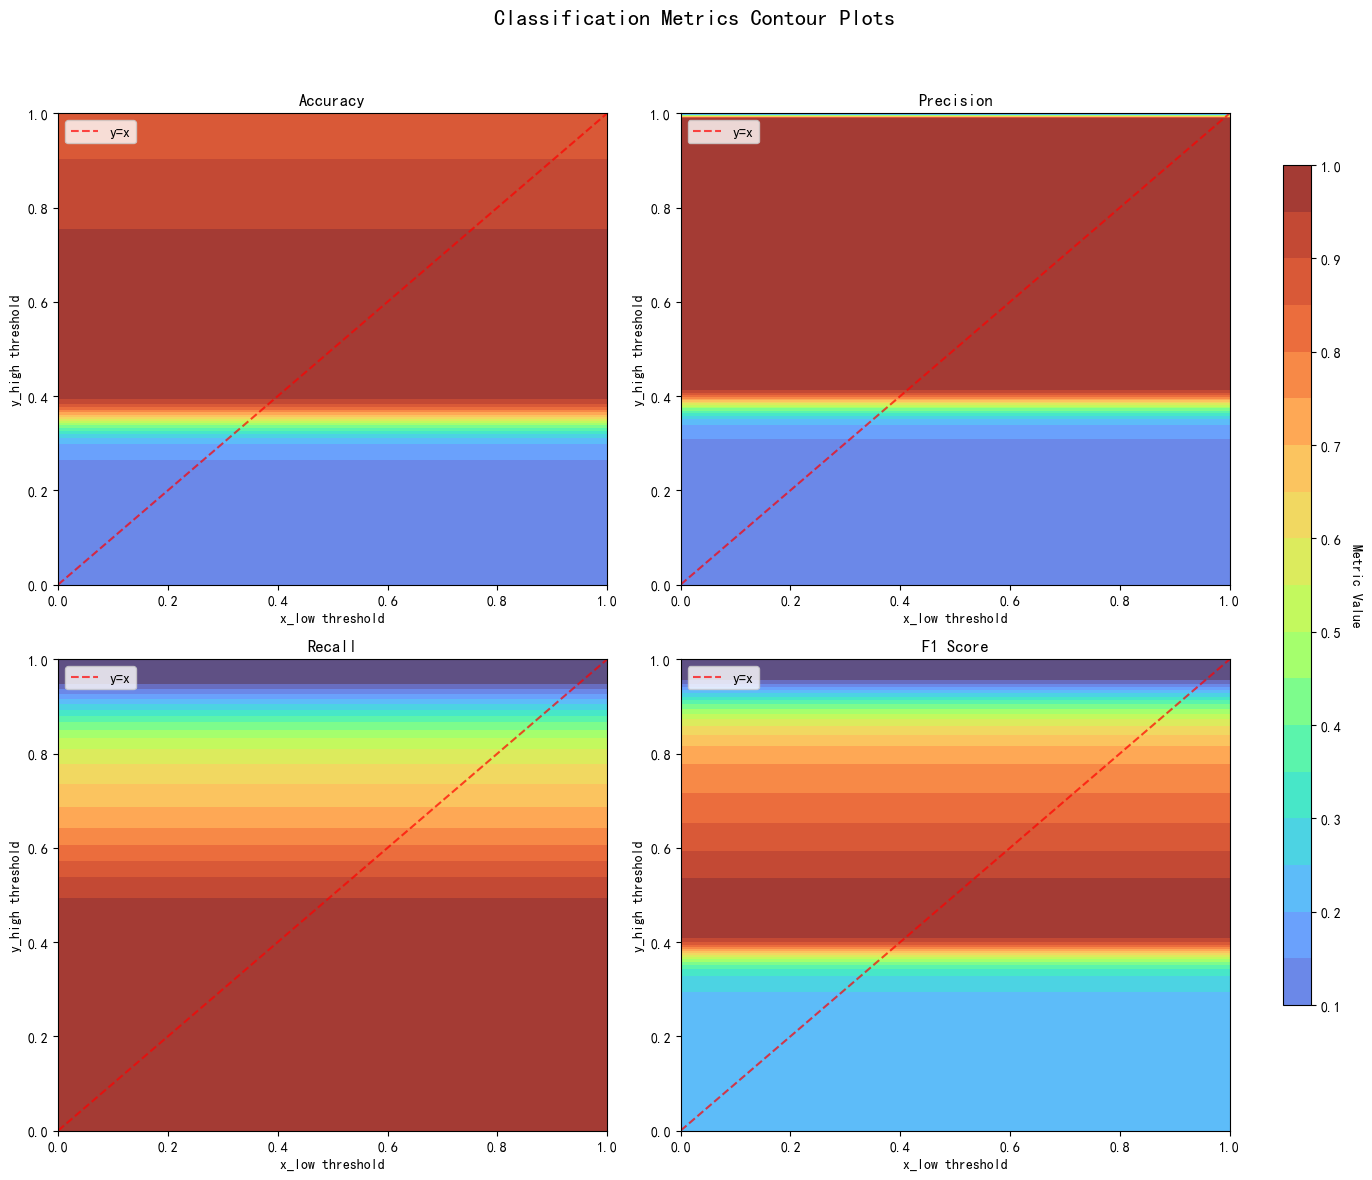

7的最小/大值：0.0013820657040923834    4.0
tp:38028, fp:681938, tn:2981, fn:69202
accuracy:0.051769300977467625, precision:0.05281916090482051, recall:0.35463955982467593, f1:0.09194435176185571, roc_auc:0.11211608834263544, score1:7.28, score2:1.21 


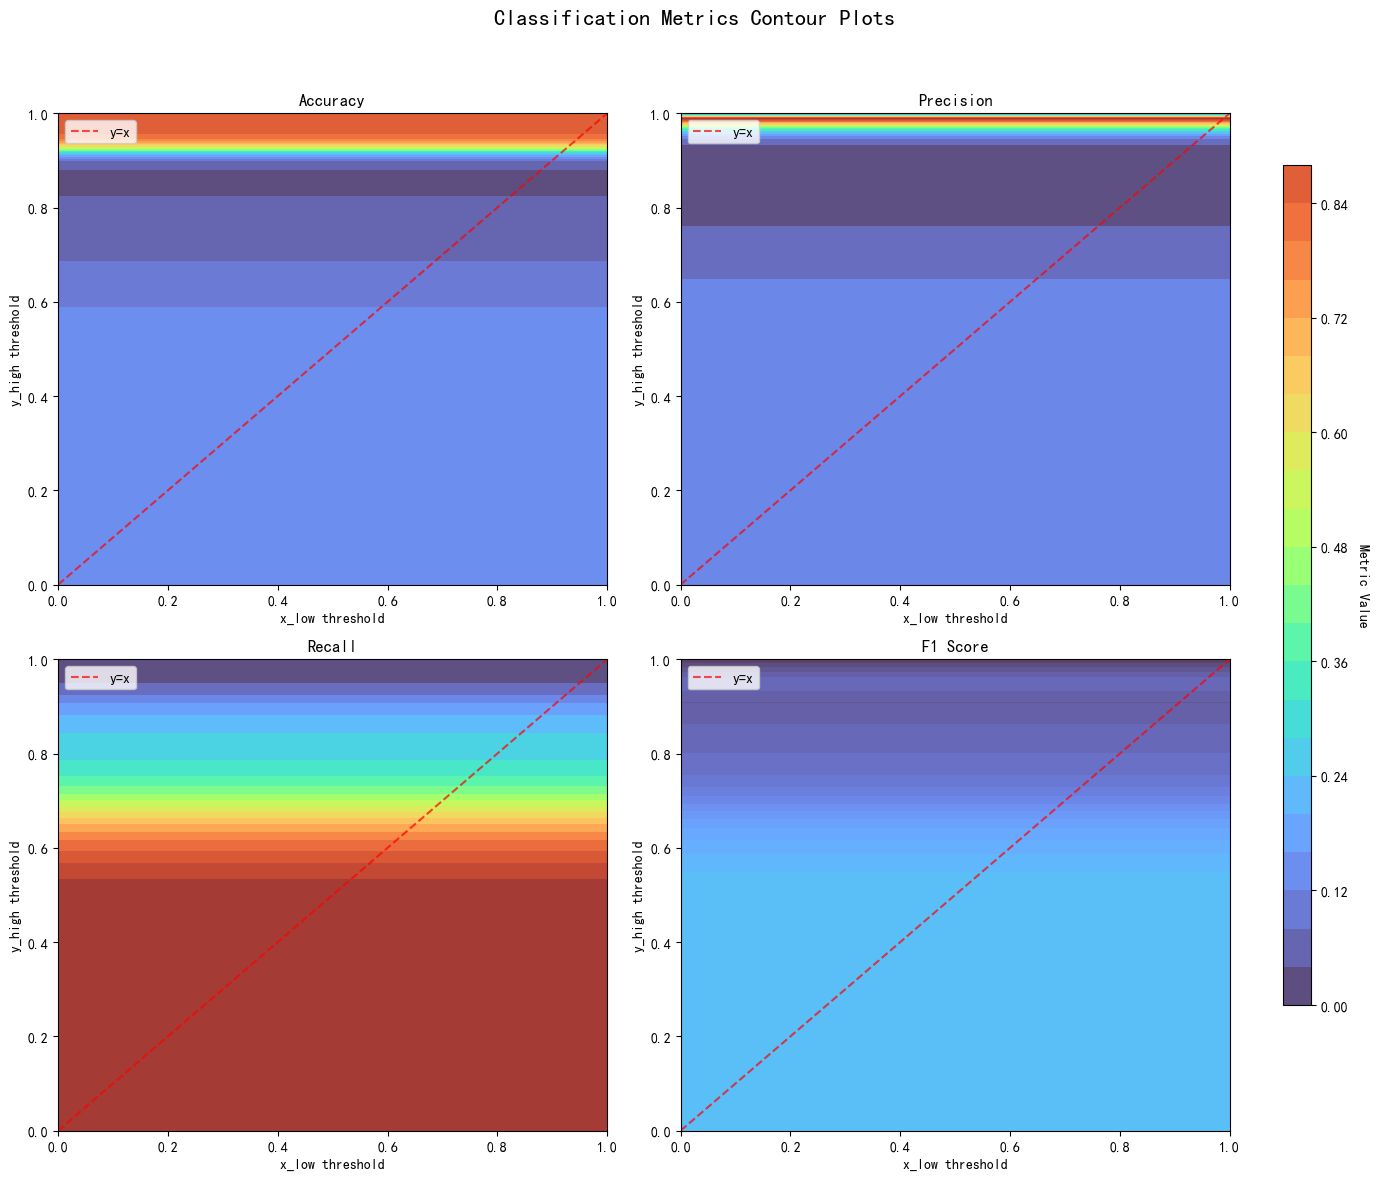

8的最小/大值：1.0    467115704320.0
tp:0, fp:0, tn:142125, fn:107230
accuracy:0.5699705239517956, precision:0, recall:0.0, f1:0, roc_auc:0.9047585339207748, score1:3.89, score2:5.52 


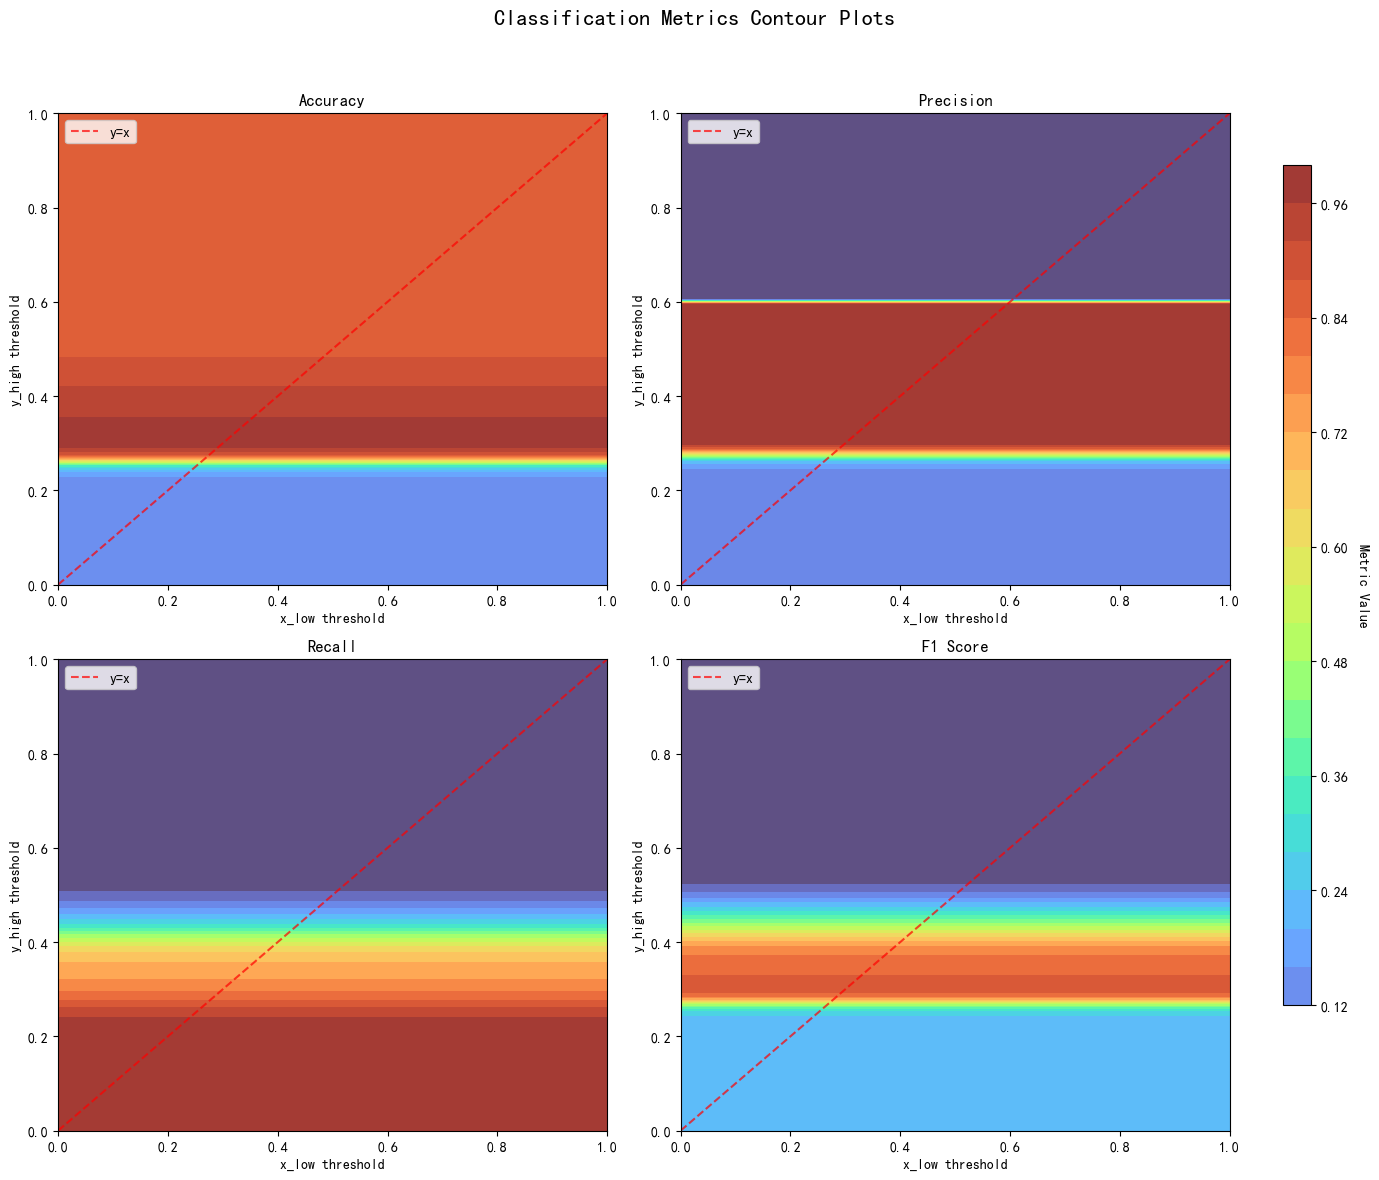

In [91]:
from utils import geodata
from sklearn.metrics import roc_auc_score, roc_curve,auc,RocCurveDisplay
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
nodata=-1e4
data,p1=geodata.read_tifs('./res/res',nodata=1)
print(data.shape)
factorsfolder=r"F:\resampled data from yousef"
# geodata.shp2tif('susceptibility_level/susceptibility_level.shp','susceptibility_level/susceptibility_level.tif',factorsfolder+'\Aspect.tif',value_field='level')
# geodata.shp2tif('susceptibility_level/susceptibility_level0.shp','susceptibility_level/susceptibility_level0.tif',factorsfolder+'\Aspect.tif')
susceptibility_level,p2=geodata.read_tifs('./susceptibility_level')
print(susceptibility_level.shape)
model=[]
High,Low=np.isin(susceptibility_level[0,0],4).flatten(),np.isin(susceptibility_level[1,0],1).flatten()
#归一化的处理方式 tp,tf,nt,nf,score,f1,auc?
for i in range(data.shape[0]):
    x=data[i][0].flatten()
    mn,mx=np.min(x),np.max(x)
    print(f'{i}的最小/大值：{mn}    {mx}')
    x=(x-mn)/(mx-mn)
    high_pred,low_pred=x[High],x[Low]             #(107230,) (685001,)
    tp=np.sum((high_pred>0.75))
    fn=np.sum((high_pred<=0.75))
    tn=np.sum((low_pred<0.25))
    fp= np.sum(low_pred>=0.5)
    print(f'tp:{tp}, fp:{fp}, tn:{tn}, fn:{fn}')

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    labels,scores=np.concatenate([np.ones(107230), np.zeros(685001)]),np.concatenate([high_pred,low_pred])
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    score1=np.sum(high_pred)/len(high_pred)
    score2=np.sum(1/np.power(10,low_pred))/len(low_pred)
    print(f'accuracy:{accuracy}, precision:{precision}, recall:{recall}, f1:{f1}, roc_auc:{roc_auc}, score1:{score1*10:.2f}, score2:{score2*10:.2f},score:{(score1+score2)*5:.2f} ')
    y_high,x_low=np.linspace(0,1,100),np.linspace(0,1,100)

    X, Y = np.meshgrid(x_low, y_high)
    accuracy_matrix = np.zeros_like(X)
    precision_matrix = np.zeros_like(X)
    recall_matrix = np.zeros_like(X)
    f1_matrix = np.zeros_like(X)
    mask = Y >= X

# 应用掩码
#     accuracy_matrix = np.ma.masked_where(~mask, accuracy_matrix)
#     precision_matrix = np.ma.masked_where(~mask, precision_matrix)
#     recall_matrix = np.ma.masked_where(~mask, recall_matrix)
#     f1_matrix = np.ma.masked_where(~mask, f1_matrix)

    # print(X)
    for i,y in enumerate(y_high):
        for j,x in enumerate(x_low):
            # if x>y:
            #     continue
            tp=np.sum((high_pred>y))
            fn=np.sum((high_pred<=y))
            tn=np.sum((low_pred<y))
            fp=np.sum((low_pred>=y))
            accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            accuracy_matrix[i, j] = accuracy
            precision_matrix[i, j] = precision
            recall_matrix[i, j] = recall
            f1_matrix[i, j] = f1
    # 创建等高线图
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Classification Metrics Contour Plots', fontsize=16)
    # cmap = plt.cm.viridis
    # cmap=plt.cm.turbo
    cmap = plt.cm.turbo
    norm = plt.Normalize(vmin=0, vmax=1)

    contour1 = axes[0, 0].contourf(X, Y, accuracy_matrix, 20, cmap=cmap, norm=norm, alpha=0.8)
    axes[0, 0].set_title('Accuracy')
    axes[0, 0].set_xlabel('x_low threshold')
    axes[0, 0].set_ylabel('y_high threshold')
    axes[0, 0].plot([x_low.min(), x_low.max()], [y_high.min(), y_high.max()], 'r--', alpha=0.7, label='y=x')
    axes[0, 0].legend()

    contour2 = axes[0, 1].contourf(X, Y, precision_matrix, 20, cmap=cmap, norm=norm, alpha=0.8)
    axes[0, 1].set_title('Precision')
    axes[0, 1].set_xlabel('x_low threshold')
    axes[0, 1].set_ylabel('y_high threshold')
    axes[0, 1].plot([x_low.min(), x_low.max()], [y_high.min(), y_high.max()], 'r--', alpha=0.7, label='y=x')
    axes[0, 1].legend()

    contour3 = axes[1, 0].contourf(X, Y, recall_matrix, 20, cmap=cmap, norm=norm, alpha=0.8)
    axes[1, 0].set_title('Recall')
    axes[1, 0].set_xlabel('x_low threshold')
    axes[1, 0].set_ylabel('y_high threshold')
    axes[1, 0].plot([x_low.min(), x_low.max()], [y_high.min(), y_high.max()], 'r--', alpha=0.7, label='y=x')
    axes[1, 0].legend()


    contour4 = axes[1, 1].contourf(X, Y, f1_matrix, 20, cmap=cmap, norm=norm, alpha=0.8)
    axes[1, 1].set_title('F1 Score')
    axes[1, 1].set_xlabel('x_low threshold')
    axes[1, 1].set_ylabel('y_high threshold')
    axes[1, 1].plot([x_low.min(), x_low.max()], [y_high.min(), y_high.max()], 'r--', alpha=0.7, label='y=x')
    axes[1, 1].legend()


    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(contour1, cax=cbar_ax)
    cbar.set_label('Metric Value', rotation=270, labelpad=15)
    plt.show()




# 3d图像不好看
#     fig = plt.figure(figsize=(16, 12))
#     ax1 = fig.add_subplot(221, projection='3d')
#     surf1 = ax1.plot_surface(X, Y, accuracy_matrix, cmap='viridis', edgecolor='none')
#     ax1.set_title('Accuracy')
#     ax1.set_xlabel('x_low threshold')
#     ax1.set_ylabel('y_high threshold')
#     ax1.set_zlabel('Accuracy')
#     fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
#
# # 精确率
#     ax2 = fig.add_subplot(222, projection='3d')
#     surf2 = ax2.plot_surface(X, Y, precision_matrix, cmap='plasma', edgecolor='none')
#     ax2.set_title('Precision')
#     ax2.set_xlabel('x_low threshold')
#     ax2.set_ylabel('y_high threshold')
#     ax2.set_zlabel('Precision')
#     fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
#
# # 召回率
#     ax3 = fig.add_subplot(223, projection='3d')
#     surf3 = ax3.plot_surface(X, Y, recall_matrix, cmap='magma', edgecolor='none')
#     ax3.set_title('Recall')
#     ax3.set_xlabel('x_low threshold')
#     ax3.set_ylabel('y_high threshold')
#     ax3.set_zlabel('Recall')
#     fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=5)
#
# # F1分数
#     ax4 = fig.add_subplot(224, projection='3d')
#     surf4 = ax4.plot_surface(X, Y, f1_matrix, cmap='inferno', edgecolor='none')
#     ax4.set_title('F1 Score')
#     ax4.set_xlabel('x_low threshold')
#     ax4.set_ylabel('y_high threshold')
#     ax4.set_zlabel('F1 Score')
#     fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=5)
#
#     plt.tight_layout()
#     plt.show()

    # roc代码废弃，图很丑
    # plt.figure(figsize=(10, 8))
    # plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.05])
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title('Receiver Operating Characteristic (ROC) Curve')
    # plt.legend(loc="lower right")
    # plt.grid(True, alpha=0.3)
    # plt.show()







In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 创建示例数据
from sklearn.datasets import make_classification

# 生成二分类数据集
X_train, y_train = make_classification(
    n_samples=1000,           # 样本数量
    n_features=17,             # 特征数量
    n_classes=1
)

print(y_train)
X_test=np.random.rand(10000,17)


# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 创建并训练逻辑回归模型
lr_model = LogisticRegression(
    penalty='l2',           # 正则化类型：l1, l2, elasticnet, none
    C=1.0,                  # 正则化强度（C越小，正则化越强）
    solver='lbfgs',         # 优化算法
    max_iter=1000,          # 最大迭代次数
    random_state=42
)

# 训练模型
lr_model.fit(X_train_scaled, y_train)

# 预测
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 0

F:\python\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
F:\python\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
F:\python\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
F:\python\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
F:\python\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
F:\python\lib\site-packages\IP

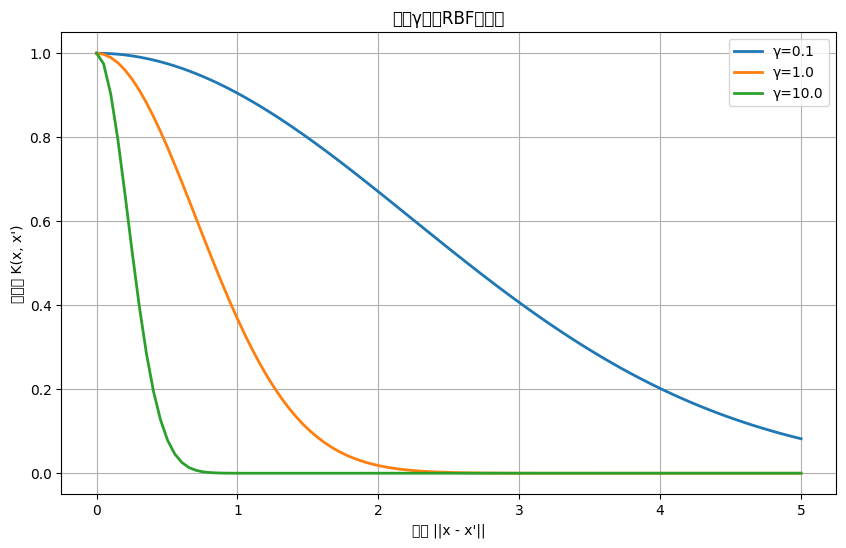

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
# 不同γ值的核函数曲线
distances = np.linspace(0, 5, 100)
gamma_values = [0.1, 1.0, 10.0]

plt.figure(figsize=(10, 6))
for gamma in gamma_values:
    similarities = np.exp(-gamma * distances**2)
    plt.plot(distances, similarities, label=f'γ={gamma}', linewidth=2)

plt.xlabel('距离 ||x - x\'||')
plt.ylabel('相似度 K(x, x\')')
plt.title('不同γ值的RBF核函数')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import rasterio
import numpy as np
from rasterio.transform import from_origin
from utils import geodata

def read_tiff_to_array(tiff_path):
    """
    读取 TIFF 文件并转换为 NumPy 数组

    参数:
        tiff_path: TIFF 文件路径

    返回:
        data: NumPy 数组
        profile: 元数据信息
    """
    with rasterio.open(tiff_path) as src:
        # 读取所有波段数据
        data = src.read()

        # 获取元数据
        profile = src.profile

        # 获取地理参考信息
        transform = src.transform
        crs = src.crs

        print(f"数据形状: {data.shape}")
        print(f"数据类型: {data.dtype}")
        print(f"波段数: {src.count}")
        print(f"影像尺寸: {src.width} x {src.height}")
        print(f"地理参考系统: {crs}")
        print(f"仿射变换参数: {transform}")

        return data, profile

def array_to_tiff(data, output_path, profile=None):
    """
    将 NumPy 数组保存为 TIFF 文件

    参数:
        data: NumPy 数组
        output_path: 输出文件路径
        profile: 元数据信息（可选）
    """
    # 如果提供了元数据，使用它
    if profile is not None:
        # 更新元数据以匹配数据
        profile.update({
            'dtype': data.dtype,
            'count': data.shape[0] if data.ndim == 3 else 1,
            'height': data.shape[-2],
            'width': data.shape[-1]
        })
    else:
        # 创建默认元数据
        if data.ndim == 2:
            # 单波段
            profile = {
                'driver': 'GTiff',
                'dtype': data.dtype,
                'count': 1,
                'height': data.shape[0],
                'width': data.shape[1],
                'crs': 'EPSG:4326',  # WGS84
                'transform': from_origin(0, data.shape[0], 1, 1)  # 默认变换
            }
        else:
            # 多波段
            profile = {
                'driver': 'GTiff',
                'dtype': data.dtype,
                'count': data.shape[0],
                'height': data.shape[1],
                'width': data.shape[2],
                'crs': 'EPSG:4326',
                'transform': from_origin(0, data.shape[1], 1, 1)
            }

    # 写入 TIFF 文件
    with rasterio.open(output_path, 'w', **profile) as dst:
        if data.ndim == 2:
            dst.write(data, 1)
        else:
            for i in range(data.shape[0]):
                dst.write(data[i], i + 1)

    print(f"TIFF 文件已保存: {output_path}")

# 使用示例
if __name__ == "__main__":
    # 读取 TIFF 文件
    input_path = r"F:\Susceptibility Assessment\res\res\CFres_RandNet_Clip44.tif"
    output_path = "res/res/CFres_RandNet_Clip44_output.tif"

    try:
        # 读取 TIFF 并转换为数组
        data, profile = read_tiff_to_array(input_path)
        data[data==np.min(data)]=0
        print(np.min(data), np.max(data))
        processed_data =1-(data-np.min(data))/(np.max(data)-np.min(data))

        # 将处理后的数组保存为新的 TIFF
        array_to_tiff(processed_data, output_path, profile)

    except Exception as e:
        print(f"错误: {e}")

数据形状: (1, 4909, 8050)
数据类型: float32
波段数: 1
影像尺寸: 8050 x 4909
地理参考系统: EPSG:32643
仿射变换参数: | 30.00, 0.00, 387486.72|
| 0.00,-30.00, 4370826.48|
| 0.00, 0.00, 1.00|
0.0 79776860.0
TIFF 文件已保存: res/res/CFres_RandNet_Clip44_output.tif


In [8]:
from sklearn.svm import OneClassSVM
import numpy as np

# 创建示例模型
X_train = np.random.randn(100, 2)  # 训练数据
clf = OneClassSVM(gamma='auto', nu=0.1)
clf.fit(X_train)

# 生成测试数据并计算分数
X_test = np.random.randn(50, 2)
scores = clf.decision_function(X_test)

print(f"分数范围: [{scores.min():.3f}, {scores.max():.3f}]")
print(f"均值: {scores.mean():.3f}")
print(f"标准差: {scores.std():.3f}")

# 分析分数分布
positive_scores = scores[scores > 0]
negative_scores = scores[scores < 0]
near_zero = scores[np.abs(scores) < 0.1]

print(f"\n正常样本数: {len(positive_scores)}")
print(f"异常样本数: {len(negative_scores)}")
print(f"边界样本数: {len(near_zero)}")

分数范围: [-0.684, 0.246]
均值: 0.066
标准差: 0.136

正常样本数: 45
异常样本数: 5
边界样本数: 30
